# Malicious URL Detection — Machine Learning Application

จำแนก URL ออกเป็น 4 ประเภท (`benign`, `defacement`, `phishing`, `malware`) จาก **ข้อความ URL เพียงอย่างเดียว**
โดยเน้น **Recall** คือจับ URL อันตรายให้ได้มากที่สุด

**ภาพรวมขั้นตอน**

```
โหลดข้อมูล → ทำความสะอาด → ตรวจ Bias → Normalize + ลบซ้ำ/ขัดแย้ง → แบ่ง Train/Val/Test ตาม host
→ สร้าง Feature 3 กลุ่ม → เทียบหลายอัลกอริทึม (บน Validation) → Tuning → Stacking
→ เลือก Threshold (บน Validation) → ประเมิน Test ครั้งเดียว
→ ทดสอบกับข้อมูลภายนอก (PhishTank, URLhaus, DeepURLBench) → พบว่าผลแย่ลง
→ หาสาเหตุ: Label Noise (Tranco, PhishStorm สลับ label, Confident Learning) → แก้ label เฉพาะ Train
→ เทรนใหม่ + เทียบ (Validation / Test / ข้อมูลภายนอกรอบที่ 2) → บันทึกโมเดลที่ดีขึ้นสำหรับ Web App
```

**กติกาที่ใช้ตลอดทั้ง Notebook:** ทุกการตัดสินใจ (เลือก feature, โมเดล, hyperparameter, threshold)
ทำบน **Validation set** เท่านั้น และเปิด **Test set เพียงครั้งเดียว** ตอนท้าย เพื่อให้ตัวเลขที่รายงานเชื่อถือได้

> เวลารันทั้ง Notebook ประมาณ 30–60 นาที (ขึ้นกับเครื่อง) และใช้ RAM ประมาณ 8–10 GB

# 1. Problem Definition

**ปัญหา:** URL อันตรายเป็นช่องทางหลักของการโจมตีทางไซเบอร์ ผู้ใช้ทั่วไปแยกด้วยตาได้ยาก
เช่น `paypal-account-verify.secure-login.xyz` ดูคล้ายของจริง

**เหตุผลที่เลือก:** เป็นปัญหาจริงที่กระทบผู้ใช้ทุกคน, ข้อมูลเปิดมีขนาดใหญ่ (6.5 แสน URL),
และสามารถสร้างเป็น Web App ให้ผู้ใช้ตรวจ URL ก่อนเปิดได้

**ประเภทของ Machine Learning:** **Multi-class Classification** (4 คลาส)

| คลาส | ความหมาย |
|---|---|
| `benign` | URL ปกติ ปลอดภัย |
| `defacement` | เว็บที่ถูกเจาะและเปลี่ยนหน้าเว็บ |
| `phishing` | เว็บปลอมเพื่อหลอกเอาข้อมูล เช่น รหัสผ่าน บัตรเครดิต |
| `malware` | URL ที่แจกจ่ายมัลแวร์หรือโปรแกรมอันตราย |

**เป้าหมายเชิงธุรกิจ:** การปล่อย URL อันตรายหลุด (False Negative) สร้างความเสียหายมากกว่าการเตือนผิด (False Positive)
จึงใช้ **Macro-F1** เป็นตัวชี้วัดหลักในการเลือกโมเดล และใช้ **Recall / Detection rate / F2-score** ในการตั้ง threshold

In [1]:
%pip install -q kagglehub

import json, time, warnings
from pathlib import Path

import joblib, kagglehub
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.feature_extraction.text import HashingVectorizer, TfidfTransformer, CountVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB, GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, f1_score, recall_score, precision_score, fbeta_score,
                             confusion_matrix, classification_report)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
LABELS = ["benign", "defacement", "malware", "phishing"]
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

def defang(s):
    """ป้องกันการกดเปิด URL อันตรายโดยไม่ตั้งใจเวลาแสดงผล"""
    return pd.Series(s, dtype="string").str.replace("http", "hxxp", regex=False).str.replace(".", "[.]", regex=False)

C:\Users\peera\AppData\Local\Temp\mudeck\venv\Scripts\python.exe: No module named pip


Note: you may need to restart the kernel to use updated packages.


C:\Users\peera\AppData\Local\Temp\mudeck\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## โมดูล `urlfeat.py` (ใช้ร่วมกันระหว่าง Notebook และ Web App)

ฟังก์ชันสร้าง feature ถูกเขียนลงไฟล์ `urlfeat.py` แล้ว import กลับมา เหตุผล:

1. **Web App ต้องแปลง URL ด้วยวิธีเดียวกับตอน train ทุกประการ** ถ้าเขียนแยกกันสองที่ อาจไม่ตรงกันโดยไม่รู้ตัว
2. `joblib` บันทึกโมเดลที่อ้างถึงฟังก์ชันนี้ได้ ถ้านิยามฟังก์ชันใน cell ของ Notebook ตรงๆ
   ตอน Web App โหลดโมเดลจะเกิด error `Can't get attribute ... on __main__`

In [2]:
%%writefile urlfeat.py
"""Feature functions shared by training (Notebook) and the Streamlit web app."""
import re
import numpy as np
import pandas as pd
import scipy.sparse as sp

SCHEME = r"^[A-Za-z][A-Za-z0-9+.-]*://"
SHORTENERS = r"bit\.ly|goo\.gl|tinyurl\.com|ow\.ly|t\.co|is\.gd|buff\.ly|adf\.ly|bitly\.com|cutt\.ly|rebrand\.ly|shorte\.st|tiny\.cc|v\.gd|j\.mp|x\.co|qr\.net|lnkd\.in|db\.tt|bit\.do"
SUS_WORDS = r"paypal|login|signin|bank|account|update|free|ebayisapi|webscr|lucky|bonus|verify|secure|confirm|password|wallet"
LABELS = ["benign", "defacement", "malware", "phishing"]


def normalize(urls):
    """ตัด scheme, www. นำหน้า และ / ท้าย ซึ่งใน dataset นี้บอกคลาสได้โดยไม่เกี่ยวกับความอันตราย"""
    s = pd.Series(urls, dtype="string").fillna("").str.strip()
    s = s.str.replace(SCHEME, "", regex=True)
    s = s.str.replace(r"^www\d?\.", "", regex=True, case=False)
    return s.str.rstrip("/")


def split_parts(s):
    host = s.str.extract(r"^([^/?#]*)", expand=False).fillna("").str.lower()
    rest = s.str.replace(r"^[^/?#]*", "", regex=True)
    path = rest.str.replace(r"[?#].*$", "", regex=True)
    query = rest.str.extract(r"\?([^#]*)", expand=False).fillna("")
    return host, path, query


def _entropy(text):
    if not text:
        return 0.0
    _, counts = np.unique(np.frombuffer(text.encode("utf-8", "ignore"), dtype=np.uint8), return_counts=True)
    p = counts / counts.sum()
    return float(-(p * np.log2(p)).sum())


LEXICAL_NAMES = [
    "url_len", "host_len", "path_len", "query_len", "n_dot", "n_host_dot", "n_hyphen", "n_host_hyphen",
    "n_at", "n_qmark", "n_amp", "n_eq", "n_underscore", "n_percent", "n_slash", "n_double_slash",
    "n_digit", "n_upper", "digit_ratio", "host_digits", "tld_len", "is_ip", "has_port", "is_shortener",
    "sus_words", "first_dir_len", "risky_ext", "entropy", "host_entropy",
]


def lexical_features(urls):
    """29 ตัวเลขเชิงโครงสร้างของ URL (คำนวณหลัง normalize)"""
    s = normalize(urls)
    host, path, query = split_parts(s)
    host_noport = host.str.replace(r":\d+$", "", regex=True)
    tld = host_noport.str.extract(r"\.([a-z0-9-]+)$", expand=False).fillna("")
    length = s.str.len().replace(0, 1)
    f = pd.DataFrame({
        "url_len": s.str.len(), "host_len": host.str.len(), "path_len": path.str.len(), "query_len": query.str.len(),
        "n_dot": s.str.count(r"\."), "n_host_dot": host.str.count(r"\."), "n_hyphen": s.str.count("-"),
        "n_host_hyphen": host.str.count("-"), "n_at": s.str.count("@"), "n_qmark": s.str.count(r"\?"),
        "n_amp": s.str.count("&"), "n_eq": s.str.count("="), "n_underscore": s.str.count("_"),
        "n_percent": s.str.count("%"), "n_slash": s.str.count("/"), "n_double_slash": s.str.count("//"),
        "n_digit": s.str.count(r"\d"), "n_upper": s.str.count(r"[A-Z]"), "digit_ratio": s.str.count(r"\d") / length,
        "host_digits": host.str.count(r"\d"), "tld_len": tld.str.len(),
        "is_ip": host_noport.str.fullmatch(r"\d{1,3}(?:\.\d{1,3}){3}").fillna(False),
        "has_port": host.str.contains(r":\d+$", regex=True),
        "is_shortener": host_noport.str.fullmatch(SHORTENERS).fillna(False),
        "sus_words": s.str.count(f"(?i)(?:{SUS_WORDS})"),
        "first_dir_len": path.str.split("/").str[1].fillna("").str.len(),
        "risky_ext": path.str.contains(r"\.(?:php|html?|exe|js|asp|aspx|cgi|zip|rar|apk|bin|scr)$", regex=True, case=False),
        "entropy": [_entropy(u) for u in s], "host_entropy": [_entropy(h) for h in host],
    })
    return f[LEXICAL_NAMES].astype(np.float32).to_numpy()


def url_tokens(url):
    """แยกคำพร้อมติดป้ายว่าอยู่ส่วนไหนของ URL (h: host, tld:, sld:, nsub:, p: path, p2: คู่คำ, q: query, ext:)"""
    m = re.match(r"^([^/?#]*)([^?#]*)\??([^#]*)", url)
    host, path, query = m.group(1).lower(), m.group(2), m.group(3)
    hp = [t for t in re.split(r"[.\-:]", host) if t]
    toks = ["h:" + t for t in hp]
    if len(hp) > 1:
        toks += ["tld:" + hp[-1], "sld:" + hp[-2], f"nsub:{min(len(hp), 6)}"]
    pt = [t for t in re.split(r"[^A-Za-z0-9]+", path) if t]
    toks += ["p:" + t.lower() for t in pt]
    toks += ["p2:" + a.lower() + "_" + b.lower() for a, b in zip(pt, pt[1:])]
    toks += ["q:" + t.lower() for t in re.split(r"[^A-Za-z0-9]+", query) if t]
    ext = re.search(r"\.([A-Za-z0-9]{1,5})$", path)
    if ext:
        toks.append("ext:" + ext.group(1).lower())
    return toks


def text_matrix(bundle, norm):
    Xc = bundle["tfidf_char"].transform(bundle["char_hash"].transform(norm))
    Xw = bundle["tfidf_word"].transform(bundle["word_hash"].transform(norm))
    return sp.hstack([Xc, Xw]).tocsr().astype(np.float32)


def predict_urls(bundle, urls):
    """ใช้ใน Web App: รับ URL ดิบ -> คลาสที่ทำนาย + ความน่าจะเป็นของแต่ละคลาส"""
    norm = normalize(urls).to_numpy(dtype=object)
    X = text_matrix(bundle, norm)
    Z = np.hstack([bundle["svc"].decision_function(X), bundle["nb"].predict_log_proba(X), lexical_features(norm)])
    P = bundle["meta"].predict_proba(Z)
    pred = np.where(P[:, 0] >= bundle["threshold"], 0, 1 + P[:, 1:].argmax(1))
    out = pd.DataFrame(P, columns=[f"P({l})" for l in LABELS])
    out.insert(0, "prediction", [LABELS[i] for i in pred])
    out.insert(0, "url", list(urls))
    return out

Overwriting urlfeat.py


In [3]:
import importlib, urlfeat
importlib.reload(urlfeat)
from urlfeat import normalize, split_parts, lexical_features, url_tokens, LEXICAL_NAMES, predict_urls
print("urlfeat.py loaded")

urlfeat.py loaded


# 2. Dataset

## 2.1 แหล่งที่มา

**Malicious URLs Dataset** โดย Manu Siddhartha (Kaggle, CC0: Public Domain, Version 1, 23 July 2021)
https://www.kaggle.com/datasets/sid321axn/malicious-urls-dataset

รวบรวมจาก 5 แหล่ง: ISCX-URL2016, Malware Domain Blacklist, Faizan GitHub repository, PhishTank และ PhishStorm

| Column | บทบาท | คำอธิบาย |
|---|---|---|
| `url` | Feature | ข้อความ URL (นำไปสร้าง feature ทั้งหมด) |
| `type` | Target | `benign`, `defacement`, `phishing`, `malware` |

> ข้อจำกัด: ไม่มีคอลัมน์วันที่และไม่มีชื่อแหล่งต้นทางรายแถว

In [4]:
csv_path = Path(kagglehub.dataset_download("sid321axn/malicious-urls-dataset")) / "malicious_phish.csv"
raw = pd.read_csv(csv_path)
print("Shape:", raw.shape)
display(raw.assign(url=defang(raw["url"])).head())

Shape: (651191, 2)


,url,type
0,br-icloud[.]com[.]br,phishing
1,mp3raid[.]com/music/krizz_kaliko[.]html,benign
2,bopsecrets[.]org/rexroth/cr/1[.]htm,benign
3,hxxp://www[.]garage-pirenne[.]be/index[.]php?option=com_content&view=article&id=70&vsig70_0=15,defacement
4,hxxp://adventure-nicaragua[.]net/index[.]php?option=com_mailto&tmpl=component&link=aHR0cDovL2Fkd...,defacement


### ผลลัพธ์ที่ได้จากการรัน
- ข้อมูลดิบ **651,191 แถว × 2 คอลัมน์** (`url`, `type`)
- URL ในตารางถูก defang (`.` → `[.]`, `http` → `hxxp`) เพื่อป้องกันการกดเปิด

,count,percent
type,,
benign,428103,65.74
defacement,96457,14.81
phishing,94111,14.45
malware,32520,4.99


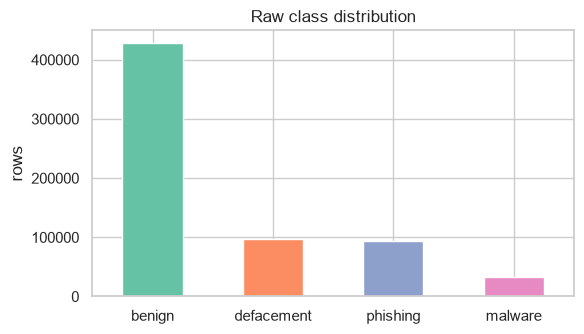

In [5]:
raw_counts = raw["type"].value_counts()
display(pd.DataFrame({"count": raw_counts, "percent": (raw_counts / len(raw) * 100).round(2)}))

ax = raw_counts.plot.bar(color=sns.color_palette("Set2", 4), figsize=(6, 3.5))
ax.set_title("Raw class distribution"); ax.set_ylabel("rows"); ax.set_xlabel("")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

### ผลลัพธ์ที่ได้จากการรัน

| Class | จำนวน | สัดส่วน |
|---|---:|---:|
| benign | 428,103 | 65.74% |
| defacement | 96,457 | 14.81% |
| phishing | 94,111 | 14.45% |
| malware | 32,520 | 4.99% |

**สรุปผล:** มีปัญหา **Class Imbalance** (malware เพียง ~5%) จึงต้องใช้ `class_weight="balanced"`
และวัดผลด้วย **Macro-F1** ซึ่งให้น้ำหนักทุกคลาสเท่ากัน แทนการดู Accuracy อย่างเดียว

# 3. Data Preprocessing

## 3.1 ทำความสะอาดพื้นฐาน

| ขั้น | เหตุผล |
|---|---|
| ตัดช่องว่าง, ปรับ label เป็นตัวพิมพ์เล็ก | ป้องกันค่าเดียวกันถูกมองเป็นคนละค่า |
| ลบ Missing / URL ว่าง / label นอก 4 คลาส | ข้อมูลใช้งานไม่ได้ |
| ลบ **Exact Duplicate** (url + type ซ้ำ) | ถ้าซ้ำอยู่ทั้ง Train และ Test โมเดลจะได้ "เห็นข้อสอบ" คะแนนสูงเกินจริง |
| ลบ URL เดียวกันที่มี **label ขัดแย้ง** | ไม่มี ground truth ที่แน่นอน |
| ลบ URL ที่มี **control characters** | ข้อความเสียหาย |

In [6]:
steps = [("raw", len(raw))]
df = raw.copy()
df["url"] = df["url"].astype("string").str.strip()
df["type"] = df["type"].astype("string").str.strip().str.lower()

df = df.dropna()
df = df[df["url"].ne("") & df["type"].isin(LABELS)]
steps.append(("drop missing / empty / invalid label", len(df)))

df = df.drop_duplicates(["url", "type"])
steps.append(("drop exact duplicates", len(df)))

df = df[df.groupby("url")["type"].transform("nunique").eq(1)]
steps.append(("drop label conflicts (raw url)", len(df)))

df = df[~df["url"].str.contains(r"[\x00-\x1F\x7F-\x9F]", regex=True)]
steps.append(("drop control characters", len(df)))

pd.DataFrame(steps, columns=["step", "rows_left"]).assign(removed=lambda d: (-d.rows_left.diff()).fillna(0).astype(int))

,step,rows_left,removed
0,raw,651191,0
1,drop missing / empty / invalid label,651191,0
2,drop exact duplicates,641125,10066
3,drop label conflicts (raw url),641113,12
4,drop control characters,641011,102


### ผลลัพธ์ที่ได้จากการรัน
- Missing / URL ว่าง / label ผิด = **0 แถว**
- Exact Duplicate = **10,066 แถว**
- URL เดียวกันแต่ label ขัดแย้ง = **12 แถว** (6 URL)
- Control characters = **102 แถว**
- เหลือ **641,011 แถว**

## 3.2 ตรวจ Bias ในรูปแบบการเขียน URL ⭐

ก่อนสร้าง feature ต้องตรวจว่ามีส่วนไหนของ URL ที่ **บอกคลาสได้โดยไม่เกี่ยวกับความอันตราย** หรือไม่
เพราะโมเดลจะเรียน "ทางลัด" นั้นแทนการเรียนสิ่งที่เราต้องการ

type                          benign  defacement  malware  phishing
               url                                                 
scheme         http              7.8       100.0     66.4      19.0
               https             0.5         0.0     28.4       7.4
               none             91.7         0.0      5.1      73.6
www            has www.          3.1        69.6      3.6      38.8
               no www.          96.9        30.4     96.4      61.2
trailing slash ends with /      26.0         0.0      3.0      27.4
               no trailing /    74.0       100.0     97.0      72.6

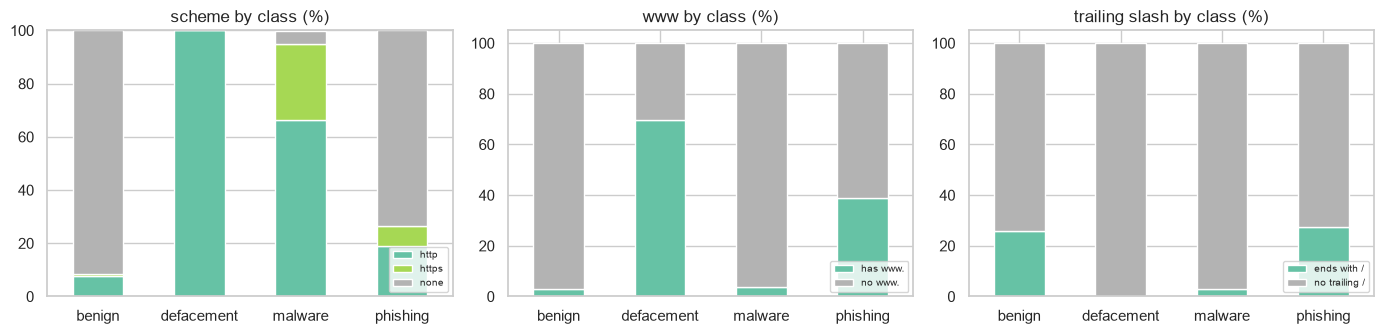

In [7]:
scheme = df["url"].str.extract(r"^(https?)://", expand=False).fillna("none")
has_www = df["url"].str.contains(r"^(?:https?://)?www\.", regex=True).map({True: "has www.", False: "no www."})
slash = df["url"].str.endswith("/").map({True: "ends with /", False: "no trailing /"})

bias = pd.concat({
    "scheme": pd.crosstab(scheme, df["type"], normalize="columns") * 100,
    "www": pd.crosstab(has_www, df["type"], normalize="columns") * 100,
    "trailing slash": pd.crosstab(slash, df["type"], normalize="columns") * 100,
}).round(1)
display(bias)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, (name, tab) in zip(axes, [("scheme", bias.loc["scheme"]), ("www", bias.loc["www"]), ("trailing slash", bias.loc["trailing slash"])]):
    tab.T.plot.bar(stacked=True, ax=ax, colormap="Set2", legend=True)
    ax.set_title(f"{name} by class (%)"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
    ax.legend(fontsize=7, loc="lower right")
plt.tight_layout(); plt.show()

### ผลลัพธ์ที่ได้จากการรัน

| ลักษณะ | benign | defacement | malware | phishing |
|---|---:|---:|---:|---:|
| **ไม่มี** `http(s)://` | **91.7%** | **0.0%** | 5.1% | 73.6% |
| มี `www.` | 3.1% | **69.6%** | 3.6% | 38.8% |
| ลงท้ายด้วย `/` | 26.0% | **0.0%** | 3.0% | 27.4% |

**สรุปผล:** defacement **ทุกแถว** มี `http://` และ **ไม่มีสักแถว** ที่ลงท้ายด้วย `/`
ส่วน benign เกือบทั้งหมดไม่มี scheme ความต่างนี้มาจาก **วิธีเก็บข้อมูลของแต่ละแหล่ง** ไม่ใช่ความอันตรายของ URL

ถ้าปล่อยไว้ โมเดลจะเรียนว่า "มี `http://` = อันตราย" และเมื่อผู้ใช้พิมพ์ `https://www.google.com` ในเว็บ ก็จะถูกทายว่าอันตราย
(จากการทดลองแยก: โมเดลที่ใช้ feature แบบนี้ได้ Macro-F1 0.90 บน test ปกติ แต่เหลือ **0.08** เมื่อเติม `https://www.` ให้ URL เดิม)

**การแก้:** **Normalize** URL ด้วยการตัด `scheme://`, `www.` และ `/` ท้าย ก่อนสร้าง feature ทุกชนิด

## 3.3 Normalize แล้วตรวจซ้ำ / ขัดแย้งอีกรอบ ⭐

หลัง normalize แล้ว `http://www.x.com/` กับ `x.com` จะกลายเป็นข้อความเดียวกัน จึงต้องลบซ้ำและตรวจ label ขัดแย้งอีกครั้ง

In [8]:
df["norm"] = normalize(df["url"])
df = df[df["norm"].ne("")]
steps.append(("drop empty after normalization", len(df)))

df = df.drop_duplicates(["norm", "type"])
steps.append(("drop duplicates after normalization", len(df)))

conflict_mask = df.groupby("norm")["type"].transform("nunique").gt(1)
conflicts = df[conflict_mask].sort_values("norm")
print("Rows in conflicting groups:", int(conflict_mask.sum()))
print("\nConflicting rows by scheme of the ORIGINAL url:")
display(pd.crosstab(conflicts["url"].str.extract(r"^(https?)://", expand=False).fillna("none"), conflicts["type"]))
print("\nExamples:")
display(conflicts.assign(url=defang(conflicts["url"]))[["url", "type"]].head(8))

df = df[~conflict_mask].reset_index(drop=True)
steps.append(("drop label conflicts after normalization", len(df)))

Rows in conflicting groups: 8044

Conflicting rows by scheme of the ORIGINAL url:


type,benign,malware,phishing
url,,,
http,0,1,3891
https,0,0,104
none,4021,1,26



Examples:


,url,type
202553,hxxp://0000502[.]rcomhost[.]com/secure-listings-redirect/products/ebaymotors/pages/SignIn[.]php?...,phishing
563465,0000502[.]rcomhost[.]com/secure-listings-redirect/products/ebaymotors/pages/SignIn[.]php?co_part...,benign
277225,hxxp://000067d[.]rcomhost[.]com/ssl/dk/sesion/confirm/ID/4571198436529353953/DANSKEBANK-DK/FRAUD...,phishing
562918,000067d[.]rcomhost[.]com/ssl/dk/sesion/confirm/ID/4571198436529353953/DANSKEBANK-DK/FRAUD/MEMBER...,benign
218222,hxxp://001234134091[.]host56[.]com/9831234193133134/,phishing
597977,001234134091[.]host56[.]com/9831234193133134/,benign
403806,hxxp://0576tz[.]com/js/?app=com-d3&amp;us[.]battle[.]net/login/en/?ref=xxhxsqbus[.]battle[.]net/...,phishing
586646,0576tz[.]com/js/?app=com-d3&amp;us[.]battle[.]net/login/en/?ref=xxhxsqbus[.]battle[.]net/d3/en/i...,benign


### ผลลัพธ์ที่ได้จากการรัน
- ลบ URL ที่ซ้ำหลัง normalize = **4,064 แถว**
- พบ label ขัดแย้งหลัง normalize = **8,044 แถว**

| URL ต้นฉบับ | benign | phishing |
|---|---:|---:|
| มี `http://` | 0 | 3,891 |
| มี `https://` | 0 | 104 |
| ไม่มี scheme | 4,021 | 26 |

**ข้อค้นพบสำคัญ:** URL phishing ประมาณ **4,000 รายการ** มี "สำเนา" ที่ถูกตัด `http://` ออกแล้วติด label ว่า **benign**
เช่น URL ที่มี `DANSKEBANK-DK/FRAUD/.../sesion/confirm` หรือ `ebaymotors/pages/SignIn.php`
ซึ่งเห็นชัดว่าเป็น phishing น่าจะเกิดจากความผิดพลาดตอนรวมข้อมูลหลายแหล่ง **ปัญหานี้จะมองไม่เห็นเลยถ้าไม่ normalize**

**การตัดสินใจ:** ลบทั้งคู่ เพราะเราไม่มีวิธียืนยันว่าฝั่งไหนถูก (ไม่แก้ label เองเพื่อไม่ใส่ความเห็นส่วนตัวลงในข้อมูล)

## 3.4 ตรวจ Label Noise ของโดเมนที่รู้จัก

In [9]:
host, _, _ = split_parts(df["norm"])
host = host.str.replace(r":\d+$", "", regex=True)
known = {}
for d in ["github.com", "microsoft.com", "google.com", "wikipedia.org", "youtube.com", "facebook.com", "amazon.com"]:
    m = host.eq(d) | host.str.endswith("." + d)
    known[d] = df.loc[m, "type"].value_counts()
pd.DataFrame(known).T.fillna(0).astype(int)

type,benign,malware,phishing
github.com,1,2,30
microsoft.com,113,6,366
google.com,868,205,616
wikipedia.org,12874,0,548
youtube.com,8626,5,7
facebook.com,8321,30,11
amazon.com,4722,0,42


### ผลลัพธ์ที่ได้จากการรัน
- โดเมนใหญ่หลายโดเมนมี label `phishing` จำนวนมาก เช่น `github.com` และ `microsoft.com`
  ส่วนหนึ่งอาจเป็นหน้า phishing ที่ฝากไว้บนบริการเหล่านี้จริง แต่บางส่วนน่าจะเป็น label ผิด
- **การตัดสินใจ:** ไม่ลบหรือแก้ label เพราะไม่มี ground truth แต่บันทึกเป็น **ข้อจำกัด** ใน Discussion
  และคาดว่าโมเดลจะทายเว็บเหล่านี้ผิดบ้าง
- *กลับมาตรวจอย่างเป็นระบบในข้อ 8 หลังพบว่าผลกับข้อมูลภายนอกไม่ดี (ข้อ 7)*

In [10]:
pd.DataFrame(steps, columns=["step", "rows_left"]).assign(removed=lambda d: (-d.rows_left.diff()).fillna(0).astype(int))

,step,rows_left,removed
0,raw,651191,0
1,drop missing / empty / invalid label,651191,0
2,drop exact duplicates,641125,10066
3,drop label conflicts (raw url),641113,12
4,drop control characters,641011,102
5,drop empty after normalization,641011,0
6,drop duplicates after normalization,636947,4064
7,drop label conflicts after normalization,628903,8044


In [11]:
clean_counts = df["type"].value_counts()
display(pd.DataFrame({"count": clean_counts, "percent": (clean_counts / len(df) * 100).round(2)}))

,count,percent
type,,
benign,422468,67.18
defacement,95308,15.15
phishing,87536,13.92
malware,23591,3.75


### สรุปการทำความสะอาด
จาก 651,191 แถว เหลือ **628,903 แถว** (ลบไป 22,288 แถว = 3.4%)

## 3.5 แบ่ง Train / Validation / Test ตาม hostname ⭐

| ชุด | สัดส่วน | ใช้ทำอะไร |
|---|---:|---|
| Train | 70% | ฝึกโมเดล |
| Validation | 10% | เลือก feature, โมเดล, hyperparameter, threshold |
| Test | 20% | วัดผลครั้งเดียวตอนจบ |

**ทำไมต้องแบ่งตาม hostname (`StratifiedGroupKFold`):** host เดียวกันมักมีหลาย URL เช่น `x.com/a`, `x.com/b`
ถ้าสุ่มธรรมดา host เดียวกันจะอยู่ทั้ง Train และ Test โมเดลแค่จำชื่อ host ก็ตอบถูก คะแนนจะสูงเกินจริง
(จากการทดลองแยก: สุ่มธรรมดาได้ Macro-F1 **0.946** แต่แบ่งตาม host ได้ **0.889** กับโมเดลเดียวกัน)

In [12]:
y = df["type"].map({l: i for i, l in enumerate(LABELS)}).to_numpy()
groups = host.where(host.ne(""), "row_" + df.index.astype(str)).to_numpy()

rest, te = next(StratifiedGroupKFold(5, shuffle=True, random_state=RANDOM_STATE).split(df["norm"], y, groups))
a, b = next(StratifiedGroupKFold(8, shuffle=True, random_state=RANDOM_STATE).split(rest, y[rest], groups[rest]))
tr, va = rest[a], rest[b]

split_table = pd.DataFrame({
    name: {"rows": len(idx), "percent": round(len(idx) / len(df) * 100, 2),
           **{LABELS[c]: round((y[idx] == c).mean() * 100, 2) for c in range(4)}}
    for name, idx in [("train", tr), ("validation", va), ("test", te)]
}).T
display(split_table)

print("host overlap train-test:", len(set(groups[tr]) & set(groups[te])))
print("host overlap train-val :", len(set(groups[tr]) & set(groups[va])))
assert not set(groups[tr]) & set(groups[te]) and not set(groups[tr]) & set(groups[va])

,rows,percent,benign,defacement,malware,phishing
train,440305.0,70.01,67.16,15.15,3.77,13.92
validation,62817.0,9.99,67.25,15.17,3.64,13.94
test,125781.0,20.00,67.17,15.15,3.75,13.92


host overlap train-test: 0
host overlap train-val : 0


### ผลลัพธ์ที่ได้จากการรัน

| ชุด | จำนวน | % | benign | defacement | malware | phishing |
|---|---:|---:|---:|---:|---:|---:|
| Train | 440,305 | 70.01 | 67.16 | 15.15 | 3.77 | 13.92 |
| Validation | 62,817 | 9.99 | 67.25 | 15.17 | 3.64 | 13.94 |
| Test | 125,781 | 20.00 | 67.17 | 15.15 | 3.75 | 13.92 |

- hostname ที่ซ้ำกันระหว่างชุด = **0** (assertion ผ่าน)
- สัดส่วนคลาสใกล้เคียงกันทุกชุด

# 4. Feature Engineering

ใช้ feature 3 กลุ่ม **ทุกกลุ่มคำนวณจาก URL ที่ normalize แล้ว** และส่วนที่ต้องเรียนรู้จากข้อมูล
(IDF ของ TF-IDF, ค่าเฉลี่ย/ส่วนเบี่ยงเบนของ StandardScaler) **fit จาก Train เท่านั้น**

| กลุ่ม | ขนาด | จับอะไร |
|---|---:|---|
| 1. Character n-gram (2–6) TF-IDF | 1,048,576 | ชิ้นตัวอักษร เช่น `payp`, `-veri` จับการสะกดเลียนแบบ |
| 2. Word token แยกตามส่วนของ URL | 524,288 | คำ + ตำแหน่ง เช่น `h:paypal`, `tld:xyz`, `p:login` |
| 3. Lexical 29 ตัว | 29 | โครงสร้าง เช่น ความยาว, จำนวน `-`, IP, entropy |

## 4.1 ตัวอย่าง feature ของ URL หนึ่งรายการ

In [13]:
example = "http://www.paypal-account-verify.secure-login.xyz/update/index.php?id=12&user=a"
ex_norm = normalize([example])[0]
print("normalized :", ex_norm)
print("\nword tokens:", url_tokens(ex_norm))
grams = CountVectorizer(analyzer="char", ngram_range=(2, 6), lowercase=False).fit([ex_norm]).get_feature_names_out()
print(f"\nchar n-grams: {len(grams)} pieces, e.g.", [g for g in grams if "payp" in g or "veri" in g][:8])
pd.Series(lexical_features([example])[0], index=LEXICAL_NAMES, name="value").round(3).to_frame().T

normalized : paypal-account-verify.secure-login.xyz/update/index.php?id=12&user=a

word tokens: ['h:paypal', 'h:account', 'h:verify', 'h:secure', 'h:login', 'h:xyz', 'tld:xyz', 'sld:login', 'nsub:6', 'p:update', 'p:index', 'p:php', 'p2:update_index', 'p2:index_php', 'q:id', 'q:12', 'q:user', 'q:a', 'ext:php']

char n-grams: 321 pieces, e.g. ['-veri', '-verif', 'payp', 'paypa', 'paypal', 't-veri', 'veri', 'verif']


,url_len,host_len,path_len,query_len,n_dot,n_host_dot,n_hyphen,n_host_hyphen,n_at,n_qmark,...,host_digits,tld_len,is_ip,has_port,is_shortener,sus_words,first_dir_len,risky_ext,entropy,host_entropy
value,68.0,38.0,17.0,12.0,3.0,2.0,3.0,3.0,0.0,1.0,...,0.0,3.0,0.0,0.0,0.0,6.0,6.0,1.0,4.587,4.201


### ผลลัพธ์ที่ได้จากการรัน
- URL หลัง normalize: `paypal-account-verify.secure-login.xyz/update/index.php?id=12&user=a`
- word token 19 ตัว เช่น `h:paypal`, `tld:xyz`, `p2:index_php`, `ext:php`
- char n-gram **321 ชิ้น** เช่น `payp`, `paypal`, `-veri`
- lexical ที่เด่น: `sus_words = 6` (paypal, account, verify, secure, login, update), `n_host_hyphen = 3`, `risky_ext = 1` (.php)

**ความหมายของ Lexical 29 ตัว**

| กลุ่มย่อย | Feature | เหตุผล |
|---|---|---|
| ความยาว | `url_len`, `host_len`, `path_len`, `query_len`, `first_dir_len` | URL อันตรายมักยาวผิดปกติเพื่อซ่อนโดเมนจริง |
| สัญลักษณ์ | `n_dot`, `n_host_dot`, `n_hyphen`, `n_host_hyphen`, `n_at`, `n_qmark`, `n_amp`, `n_eq`, `n_underscore`, `n_percent`, `n_slash`, `n_double_slash` | subdomain ซ้อน, ขีดต่อคำ, `@` หลอกตา, `//` ซ้อน URL, พารามิเตอร์ของเว็บ CMS |
| ตัวเลข/ตัวอักษร | `n_digit`, `digit_ratio`, `host_digits`, `n_upper` | URL ที่สร้างอัตโนมัติมีตัวเลข/ตัวสุ่มมาก |
| โดเมน | `tld_len`, `is_ip`, `has_port`, `is_shortener` | ใช้ IP ตรงๆ, port แปลก, ลิงก์ย่อที่ซ่อนปลายทาง |
| เนื้อหา | `sus_words`, `risky_ext` | คำล่อลวง (login, verify, bank...) และนามสกุลไฟล์เสี่ยง (.exe, .php...) |
| ความสุ่ม | `entropy`, `host_entropy` | ข้อความสุ่ม/โดเมนที่สร้างด้วยโปรแกรม (DGA) มี entropy สูง |

**Feature ที่ตั้งใจไม่ใช้:** มี `http`/`https`, นับ `www`, มี `/` ท้าย — เพราะเป็น bias ของ dataset (หัวข้อ 3.2)

## 4.2 สร้าง feature ทั้งหมด

ใช้ `HashingVectorizer` แทน `TfidfVectorizer` เพราะข้อมูล 6 แสนแถว × n-gram 2–6 ตัวอักษร
มีคำศัพท์หลายสิบล้านแบบ ถ้าเก็บ vocabulary จะใช้ RAM มาก การ hash แปลงชิ้นเป็นเลขช่องโดยตรงจึงประหยัดกว่า
แล้วค่อยคูณด้วย IDF ผ่าน `TfidfTransformer` ที่ fit จาก Train

In [14]:
norm = df["norm"].to_numpy(dtype=object)

L = lexical_features(norm)
scaler = StandardScaler().fit(L[tr])
Ls = scaler.transform(L).astype(np.float32)

word_hash = HashingVectorizer(analyzer=url_tokens, n_features=2**19, alternate_sign=False, norm=None, dtype=np.float32)
W = word_hash.transform(norm)

def char_hash(lo, hi):
    return HashingVectorizer(analyzer="char", ngram_range=(lo, hi), n_features=2**20, alternate_sign=False,
                             lowercase=False, norm=None, dtype=np.float32)

def tfidf(M):
    t = TfidfTransformer(sublinear_tf=True).fit(M[tr])      # IDF learned from TRAIN only
    return t, t.transform(M).tocsr().astype(np.float32)

print("lexical:", L.shape, "| word tokens:", W.shape, "nnz =", W.nnz)

lexical: (628903, 29) | word tokens: (628903, 524288) nnz = 9587365


# 5. Machine Learning Model

## 5.0 ตัวชี้วัด

| ตัวชี้วัด | ความหมาย |
|---|---|
| **Macro-F1** | ค่าเฉลี่ย F1 ของ 4 คลาสแบบให้น้ำหนักเท่ากัน — **ใช้เลือกโมเดล** |
| Detection rate | URL อันตรายทั้งหมด ถูกทายเป็น "อันตรายประเภทใดก็ได้" กี่ % |
| False alarm | URL ปกติ ถูกทายว่าอันตรายกี่ % |
| F2 (malicious) | F-score แบบให้ Recall สำคัญกว่า Precision 2 เท่า — **ใช้ตั้ง threshold** |
| Recall รายคลาส | แต่ละประเภทจับได้กี่ % |

In [15]:
def metrics(y_true, y_pred):
    mal = y_true != 0
    r = recall_score(y_true, y_pred, average=None, labels=range(4))
    return dict(acc=accuracy_score(y_true, y_pred), macro_f1=f1_score(y_true, y_pred, average="macro"),
                macro_precision=precision_score(y_true, y_pred, average="macro"),
                macro_recall=recall_score(y_true, y_pred, average="macro"),
                detect_rate=(y_pred[mal] != 0).mean(), false_alarm=(y_pred[~mal] != 0).mean(),
                f2_malicious=fbeta_score(mal, y_pred != 0, beta=2),
                **{f"rec_{l}": r[i] for i, l in enumerate(LABELS)})

experiments = []
def evaluate(stage, features, model, params, clf, Xtr, Xva, fit_rows=None):
    fit_rows = tr if fit_rows is None else fit_rows
    start = time.time(); clf.fit(Xtr, y[fit_rows]); sec = time.time() - start
    row = dict(stage=stage, features=features, model=model, params=params, fit_sec=round(sec, 1), **metrics(y[va], clf.predict(Xva)))
    experiments.append(row)
    print(f"{model:22s} {params:20s} val macro-F1={row['macro_f1']:.4f}  detect={row['detect_rate']:.3f}  "
          f"false-alarm={row['false_alarm']:.3f}  ({sec:.0f}s)")
    return clf, row

SHOW = ["model", "params", "features", "macro_f1", "detect_rate", "false_alarm", "rec_defacement", "rec_malware", "rec_phishing", "fit_sec"]

## 5.1 Lexical features × อัลกอริทึมพื้นฐาน 6 แบบ

เริ่มจาก feature ขนาดเล็ก (29 ตัว) เพื่อเทียบอัลกอริทึมหลายแบบตามที่เรียนในรายวิชา
- โมเดลที่ไวต่อสเกล (Logistic Regression, Naive Bayes, KNN) ใช้ feature ที่ผ่าน `StandardScaler`
- KNN ใช้ train สุ่ม 100,000 แถว เพราะต้องคำนวณระยะทางกับทุกแถวตอนทำนาย ถ้าใช้ทั้งหมดจะช้ามาก

In [16]:
knn_rows = np.random.default_rng(RANDOM_STATE).choice(tr, 100_000, replace=False)
lex = {}
lex["LogisticRegression"], _ = evaluate("5.1 lexical", "29 lexical", "LogisticRegression", "", LogisticRegression(class_weight="balanced", max_iter=2000), Ls[tr], Ls[va])
lex["GaussianNB"], _ = evaluate("5.1 lexical", "29 lexical", "GaussianNB", "", GaussianNB(), Ls[tr], Ls[va])
lex["KNN"], _ = evaluate("5.1 lexical", "29 lexical", "KNN", "k=15, 100k rows", KNeighborsClassifier(15, weights="distance", n_jobs=-1), Ls[knn_rows], Ls[va], fit_rows=knn_rows)
lex["DecisionTree"], _ = evaluate("5.1 lexical", "29 lexical", "DecisionTree", "min_leaf=5", DecisionTreeClassifier(class_weight="balanced", min_samples_leaf=5, random_state=RANDOM_STATE), L[tr], L[va])
lex["RandomForest"], _ = evaluate("5.1 lexical", "29 lexical", "RandomForest", "300 trees", RandomForestClassifier(300, class_weight="balanced_subsample", min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE), L[tr], L[va])

best_hgb, best_hgb_f1 = None, -1
for lr_, leaves in [(0.1, 31), (0.1, 127), (0.05, 255)]:
    clf, row = evaluate("5.1 lexical", "29 lexical", "HistGradientBoosting", f"lr={lr_}, leaves={leaves}",
                        HistGradientBoostingClassifier(learning_rate=lr_, max_leaf_nodes=leaves, max_iter=500, class_weight="balanced", random_state=RANDOM_STATE), L[tr], L[va])
    if row["macro_f1"] > best_hgb_f1:
        best_hgb, best_hgb_f1 = clf, row["macro_f1"]

pd.DataFrame([e for e in experiments if e["stage"] == "5.1 lexical"])[SHOW].round(4).sort_values("macro_f1", ascending=False)

LogisticRegression                          val macro-F1=0.6046  detect=0.882  false-alarm=0.420  (6s)


GaussianNB                                  val macro-F1=0.3023  detect=0.974  false-alarm=0.937  (0s)


KNN                    k=15, 100k rows      val macro-F1=0.7157  detect=0.622  false-alarm=0.087  (0s)


DecisionTree           min_leaf=5           val macro-F1=0.6560  detect=0.802  false-alarm=0.286  (5s)


RandomForest           300 trees            val macro-F1=0.7605  detect=0.732  false-alarm=0.142  (49s)


HistGradientBoosting   lr=0.1, leaves=31    val macro-F1=0.6998  detect=0.855  false-alarm=0.338  (43s)


HistGradientBoosting   lr=0.1, leaves=127   val macro-F1=0.7367  detect=0.836  false-alarm=0.258  (34s)


HistGradientBoosting   lr=0.05, leaves=255  val macro-F1=0.7444  detect=0.835  false-alarm=0.236  (57s)


,model,params,features,macro_f1,detect_rate,false_alarm,rec_defacement,rec_malware,rec_phishing,fit_sec
4,RandomForest,300 trees,29 lexical,0.7605,0.7325,0.1423,0.8051,0.6884,0.5876,49.1
7,HistGradientBoosting,"lr=0.05, leaves=255",29 lexical,0.7444,0.8351,0.2358,0.8216,0.7015,0.7592,56.7
6,HistGradientBoosting,"lr=0.1, leaves=127",29 lexical,0.7367,0.8362,0.2580,0.8181,0.6985,0.7646,34.3
2,KNN,"k=15, 100k rows",29 lexical,0.7157,0.6220,0.0869,0.7982,0.6792,0.3315,0.0
5,HistGradientBoosting,"lr=0.1, leaves=31",29 lexical,0.6998,0.8554,0.3385,0.8469,0.6950,0.7745,43.0
3,DecisionTree,min_leaf=5,29 lexical,0.6560,0.8015,0.2856,0.7801,0.6788,0.6464,5.0
0,LogisticRegression,,29 lexical,0.6046,0.8815,0.4205,0.7994,0.8092,0.7279,5.9
1,GaussianNB,,29 lexical,0.3023,0.9745,0.9374,0.9918,0.6455,0.0495,0.1


### ผลลัพธ์ที่ได้จากการรัน (Validation)

| โมเดล | Macro-F1 | Detection | False alarm |
|---|---:|---:|---:|
| **RandomForest** | **0.761** | 73.3% | 14.2% |
| HistGradientBoosting (lr=0.05, leaves=255) | 0.744 | 83.5% | 23.6% |
| KNN | 0.716 | 62.2% | 8.7% |
| DecisionTree | 0.656 | 80.2% | 28.6% |
| LogisticRegression | 0.605 | 88.2% | 42.1% |
| GaussianNB | 0.302 | 97.5% | 93.7% |

**สรุปผล:**
- โมเดลแบบต้นไม้ (RandomForest, HistGB) ดีที่สุด เพราะจับความสัมพันธ์แบบไม่เป็นเส้นตรงของ feature ได้
- GaussianNB แย่มาก เพราะสมมติว่า feature เป็นอิสระต่อกันและกระจายแบบปกติ ซึ่งไม่จริง (เช่น `url_len` กับ `n_slash` สัมพันธ์กันสูง)
- **ข้อจำกัดของกลุ่มนี้:** ตัวเลขโครงสร้างอย่างเดียวไม่รู้ว่า URL "มีคำอะไร" คะแนนจึงตันที่ประมาณ 0.76

## 5.2 เลือกรูปแบบ Text feature

ใช้ `LinearSVC` (C=0.3) เป็นตัวทดสอบ เพราะเร็วและเหมาะกับ feature แบบ sparse มิติสูง
เพื่อเทียบว่ารูปแบบไหนให้ข้อมูลมากที่สุด

In [17]:
svc_probe = lambda: LinearSVC(class_weight="balanced", C=0.3)

_, X = tfidf(char_hash(3, 5).transform(norm))
evaluate("5.2 representation", "char 3-5", "LinearSVC", "C=0.3", svc_probe(), X[tr], X[va]); del X

tfidf_char, Xc = tfidf(char_hash(2, 6).transform(norm))
evaluate("5.2 representation", "char 2-6", "LinearSVC", "C=0.3", svc_probe(), Xc[tr], Xc[va])

tfidf_word, Xw = tfidf(W)
evaluate("5.2 representation", "word tokens", "LinearSVC", "C=0.3", svc_probe(), Xw[tr], Xw[va])

XT = sp.hstack([Xc, Xw]).tocsr(); del Xc, Xw
evaluate("5.2 representation", "char 2-6 + word", "LinearSVC", "C=0.3", svc_probe(), XT[tr], XT[va])

pd.DataFrame([e for e in experiments if e["stage"] == "5.2 representation"])[SHOW].round(4)

LinearSVC              C=0.3                val macro-F1=0.8438  detect=0.829  false-alarm=0.055  (33s)


LinearSVC              C=0.3                val macro-F1=0.8457  detect=0.825  false-alarm=0.055  (43s)


LinearSVC              C=0.3                val macro-F1=0.8033  detect=0.722  false-alarm=0.057  (12s)


LinearSVC              C=0.3                val macro-F1=0.8474  detect=0.806  false-alarm=0.043  (55s)


,model,params,features,macro_f1,detect_rate,false_alarm,rec_defacement,rec_malware,rec_phishing,fit_sec
0,LinearSVC,C=0.3,char 3-5,0.8438,0.8289,0.0553,0.7821,0.7479,0.7752,33.0
1,LinearSVC,C=0.3,char 2-6,0.8457,0.8246,0.0549,0.7805,0.7457,0.7830,43.1
2,LinearSVC,C=0.3,word tokens,0.8033,0.7217,0.0566,0.7315,0.7597,0.6035,11.8
3,LinearSVC,C=0.3,char 2-6 + word,0.8474,0.8057,0.0432,0.7647,0.7549,0.7600,54.6


### ผลลัพธ์ที่ได้จากการรัน (Validation)

| Representation | Macro-F1 | เวลา train |
|---|---:|---:|
| word tokens | 0.803 | ~10 วินาที |
| char 3–5 | 0.844 | ~30 วินาที |
| char 2–6 | 0.846 | ~40 วินาที |
| **char 2–6 + word** | **0.847** | ~50 วินาที |
| char 2–6 + word + lexical *(ทดลองแยก)* | 0.850 | **~1,600 วินาที** |

**สรุปผล:**
- Text feature ดีกว่า Lexical อย่างชัดเจน (0.85 เทียบกับ 0.76) เพราะรู้ว่า URL มี "คำ/ชิ้นอะไร"
- char 2–6 ดีกว่า 3–5 เพราะชิ้นยาว 6 ตัวจับคำเต็ม เช่น `paypal` ได้
- **char + word ดีที่สุด** เพราะจับข้อมูลคนละแบบ: char จับการสะกด ส่วน word จับตำแหน่งของคำ
- การใส่ lexical เข้าไปใน LinearSVC ด้วยได้เพิ่มแค่ +0.003 แต่ช้ากว่า **37 เท่า**
  **เกณฑ์ที่ใช้เลือก:** เลือกตัวที่ดีที่สุดในกลุ่มที่ train ได้ภายใน 5 นาที แล้วค่อยนำ lexical ไปใช้ในชั้น Stacking (หัวข้อ 5.4) แทน

## 5.3 Hyperparameter Tuning (บน char 2–6 + word)

| โมเดล | Hyperparameter | ความหมาย |
|---|---|---|
| LinearSVC | `C` | ค่าน้อย = regularize มาก = โมเดลเรียบง่าย ไม่จำ train มากเกินไป |
| ComplementNB | `alpha` | smoothing สำหรับ n-gram ที่พบน้อย |
| LogisticRegression | `C` | เหมือน LinearSVC แต่ให้ผลเป็นความน่าจะเป็น |

In [18]:
best = {}
for C in [0.1, 0.3, 1.0]:
    clf, row = evaluate("5.3 tuning", "char 2-6 + word", "LinearSVC", f"C={C}", LinearSVC(class_weight="balanced", C=C), XT[tr], XT[va])
    if row["macro_f1"] > best.get("svc", (None, -1))[1]:
        best["svc"] = (clf, row["macro_f1"], C)

for alpha in [0.01, 0.05, 0.2]:
    clf, row = evaluate("5.3 tuning", "char 2-6 + word", "ComplementNB", f"alpha={alpha}", ComplementNB(alpha=alpha), XT[tr], XT[va])
    if row["macro_f1"] > best.get("nb", (None, -1))[1]:
        best["nb"] = (clf, row["macro_f1"], alpha)

for C in [4, 16]:   # slowest block (~5-8 minutes per fit)
    clf, row = evaluate("5.3 tuning", "char 2-6 + word", "LogisticRegression", f"C={C}", LogisticRegression(class_weight="balanced", C=C, max_iter=300), XT[tr], XT[va])
    if row["macro_f1"] > best.get("lr", (None, -1))[1]:
        best["lr"] = (clf, row["macro_f1"], C)

best_svc, _, best_C = best["svc"]; best_nb, _, best_alpha = best["nb"]; best_lr, _, best_lr_C = best["lr"]
print(f"\nbest LinearSVC C={best_C} | best ComplementNB alpha={best_alpha} | best LogisticRegression C={best_lr_C}")
pd.DataFrame([e for e in experiments if e["stage"] == "5.3 tuning"])[SHOW].round(4)

LinearSVC              C=0.1                val macro-F1=0.8494  detect=0.813  false-alarm=0.049  (40s)


LinearSVC              C=0.3                val macro-F1=0.8474  detect=0.806  false-alarm=0.043  (51s)


LinearSVC              C=1.0                val macro-F1=0.8419  detect=0.790  false-alarm=0.038  (85s)


ComplementNB           alpha=0.01           val macro-F1=0.7536  detect=0.590  false-alarm=0.019  (2s)


ComplementNB           alpha=0.05           val macro-F1=0.7813  detect=0.653  false-alarm=0.026  (3s)


ComplementNB           alpha=0.2            val macro-F1=0.8031  detect=0.722  false-alarm=0.040  (2s)


LogisticRegression     C=4                  val macro-F1=0.8507  detect=0.855  false-alarm=0.063  (412s)


LogisticRegression     C=16                 val macro-F1=0.8512  detect=0.831  false-alarm=0.051  (470s)

best LinearSVC C=0.1 | best ComplementNB alpha=0.2 | best LogisticRegression C=16


,model,params,features,macro_f1,detect_rate,false_alarm,rec_defacement,rec_malware,rec_phishing,fit_sec
0,LinearSVC,C=0.1,char 2-6 + word,0.8494,0.8130,0.0488,0.7851,0.7549,0.7655,40.5
1,LinearSVC,C=0.3,char 2-6 + word,0.8474,0.8057,0.0432,0.7647,0.7549,0.7600,51.3
2,LinearSVC,C=1.0,char 2-6 + word,0.8419,0.7898,0.0381,0.7422,0.7532,0.7408,84.9
3,ComplementNB,alpha=0.01,char 2-6 + word,0.7536,0.5899,0.0195,0.7463,0.6950,0.3432,2.2
4,ComplementNB,alpha=0.05,char 2-6 + word,0.7813,0.6525,0.0264,0.7869,0.7077,0.4294,2.6
5,ComplementNB,alpha=0.2,char 2-6 + word,0.8031,0.7216,0.0395,0.8190,0.7239,0.5272,1.9
6,LogisticRegression,C=4,char 2-6 + word,0.8507,0.8548,0.0634,0.7883,0.7562,0.8275,412.1
7,LogisticRegression,C=16,char 2-6 + word,0.8512,0.8314,0.0514,0.7784,0.7571,0.7959,469.6


### ผลลัพธ์ที่ได้จากการรัน (Validation)

| โมเดล | ค่าที่ลอง → Macro-F1 | ดีที่สุด |
|---|---|---|
| LinearSVC | C=0.1 → **0.849**, C=0.3 → 0.847, C=1.0 → 0.842 | **C = 0.1** |
| ComplementNB | α=0.01 → 0.754, α=0.05 → 0.781, α=0.2 → **0.803** | **α = 0.2** |
| LogisticRegression | C=4 → 0.851, C=16 → **0.851** | **C = 16** |

**สรุปผล:**
- LinearSVC ยิ่ง C เล็ก (regularize มาก) ยิ่งดี แปลว่าข้อมูลมี noise ถ้าปล่อยให้โมเดลซับซ้อนจะจำ noise
- ComplementNB ดีขึ้นเมื่อ α มากขึ้น และค่าดีสุดอยู่ที่ขอบของช่วงที่ลอง (ลองค่าสูงกว่านี้ได้อีก)
- ComplementNB แจ้งเตือนผิดน้อยมาก แต่จับ phishing ได้ไม่ดี จึงเหมาะเป็น "ผู้ช่วย" มากกว่าตัวหลัก
- ทุกโมเดลตันที่ประมาณ **0.85** → ต้องใช้การรวมโมเดลในหัวข้อถัดไป

## 5.4 Stacking: รวมจุดแข็งของหลายโมเดล ⭐

```
ชั้นที่ 1:  URL → [char+word TF-IDF] → LinearSVC  → คะแนน 4 คลาส
                                    → ComplementNB → log-prob 4 คลาส
ชั้นที่ 2:  [คะแนน 8 ตัว + lexical 29 ตัว] → HistGradientBoosting → คำตอบสุดท้าย
```

**ทำไมต้องทำ Out-of-fold:** ถ้าใช้โมเดลชั้น 1 ที่ train กับ Train ทั้งก้อนมาให้คะแนน Train เดิม
คะแนนจะมั่นใจเกินจริง (เพราะเคยเห็นแล้ว) ชั้น 2 จะเรียนผิด จึงแบ่ง Train เป็น 3 ส่วน **ตาม host**
แล้วให้คะแนนแต่ละส่วนด้วยโมเดลที่ train จากอีก 2 ส่วน

In [19]:
def base_scores(svc, nb, rows):
    return np.hstack([svc.decision_function(XT[rows]), nb.predict_log_proba(XT[rows])]).astype(np.float32)

oof = np.zeros((len(tr), 8), np.float32)
for k, (i, j) in enumerate(StratifiedGroupKFold(3, shuffle=True, random_state=1).split(tr, y[tr], groups[tr])):
    svc_k = LinearSVC(class_weight="balanced", C=best_C).fit(XT[tr[i]], y[tr[i]])
    nb_k = ComplementNB(alpha=best_alpha).fit(XT[tr[i]], y[tr[i]])
    oof[j] = base_scores(svc_k, nb_k, tr[j])
    print("out-of-fold", k, "done")

Z_tr = np.hstack([oof, L[tr]])
Z_va = np.hstack([base_scores(best_svc, best_nb, va), L[va]])
Z_te = np.hstack([base_scores(best_svc, best_nb, te), L[te]])

best_meta, best_meta_f1 = None, -1
for lr_, leaves in [(0.1, 31), (0.05, 63), (0.05, 127)]:
    meta = HistGradientBoostingClassifier(learning_rate=lr_, max_leaf_nodes=leaves, max_iter=600, class_weight="balanced", random_state=RANDOM_STATE)
    start = time.time(); meta.fit(Z_tr, y[tr])
    row = dict(stage="5.4 stacking", features="SVC+NB scores + 29 lexical", model="Stacking (HistGB meta)",
               params=f"lr={lr_}, leaves={leaves}", fit_sec=round(time.time() - start, 1), **metrics(y[va], meta.predict(Z_va)))
    experiments.append(row); print(f"meta lr={lr_} leaves={leaves}: val macro-F1={row['macro_f1']:.4f}")
    if row["macro_f1"] > best_meta_f1:
        best_meta, best_meta_f1 = meta, row["macro_f1"]

# ablation: remove lexical from the meta layer
abl = HistGradientBoostingClassifier(max_iter=600, class_weight="balanced", random_state=RANDOM_STATE).fit(Z_tr[:, :8], y[tr])
experiments.append(dict(stage="5.4 stacking", features="SVC+NB scores only", model="Stacking (ablation)", params="no lexical",
                        fit_sec=0, **metrics(y[va], abl.predict(Z_va[:, :8]))))
pd.DataFrame([e for e in experiments if e["stage"] == "5.4 stacking"])[SHOW].round(4)

out-of-fold 0 done


out-of-fold 1 done


out-of-fold 2 done


meta lr=0.1 leaves=31: val macro-F1=0.8497


meta lr=0.05 leaves=63: val macro-F1=0.8582


meta lr=0.05 leaves=127: val macro-F1=0.8578


,model,params,features,macro_f1,detect_rate,false_alarm,rec_defacement,rec_malware,rec_phishing,fit_sec
0,Stacking (HistGB meta),"lr=0.1, leaves=31",SVC+NB scores + 29 lexical,0.8497,0.9404,0.1290,0.9279,0.8035,0.8874,10.8
1,Stacking (HistGB meta),"lr=0.05, leaves=63",SVC+NB scores + 29 lexical,0.8582,0.9263,0.1078,0.9121,0.7825,0.8806,48.2
2,Stacking (HistGB meta),"lr=0.05, leaves=127",SVC+NB scores + 29 lexical,0.8578,0.9241,0.1055,0.9100,0.7807,0.8758,37.8
3,Stacking (ablation),no lexical,SVC+NB scores only,0.8217,0.9410,0.1399,0.9159,0.8000,0.8678,0.0


### ผลลัพธ์ที่ได้จากการรัน (Validation)

| Meta model | Macro-F1 | Detection | False alarm |
|---|---:|---:|---:|
| HistGB lr=0.1, leaves=31 | 0.850 | 94.0% | 12.9% |
| **HistGB lr=0.05, leaves=63** | **0.858** | 92.6% | 10.8% |
| HistGB lr=0.05, leaves=127 | 0.858 | 92.4% | 10.6% |
| *Ablation: ไม่ใส่ lexical* | 0.822 | 94.1% | 14.0% |

**สรุปผล:**
- Stacking ได้ **0.858** ดีกว่าโมเดลเดี่ยวที่ดีที่สุด (LogReg 0.851) และ Detection เพิ่มจาก ~83% เป็น **92.6%** (leaves=63 ชนะ leaves=127 ที่ทศนิยมตำแหน่งที่ 4: 0.8582 เทียบกับ 0.8578)
- **Ablation พิสูจน์ว่า lexical มีประโยชน์:** ถ้าตัดออก Macro-F1 ลดเหลือ 0.822 (**−0.037**)
  แปลว่า text บอกว่า URL "มีคำอะไร" ส่วน lexical บอกว่า URL "หน้าตาเป็นยังไง" สองอย่างนี้เสริมกัน
- HistGB เรียนการผสมแบบไม่เป็นเส้นตรงได้ เช่น "SVC ไม่แน่ใจ + query ยาว + ลงท้าย .php → defacement\"

## 5.5 ตั้ง Threshold เพื่อเน้น Recall (บน Validation)

ปกติโมเดลเลือกคลาสที่ความน่าจะเป็นสูงสุด (argmax) แต่เราต้องการ **จับของอันตรายให้ได้มาก** จึงใช้กฎ:

> ทายว่า `benign` **เฉพาะเมื่อ** P(benign) ≥ threshold ไม่อย่างนั้นทายเป็นคลาสอันตรายที่น่าจะเป็นที่สุด

เลือก threshold ที่ให้ **F2-score** (Recall สำคัญกว่า Precision 2 เท่า) สูงสุด **บน Validation**

chosen threshold (max F2 on validation): 0.6


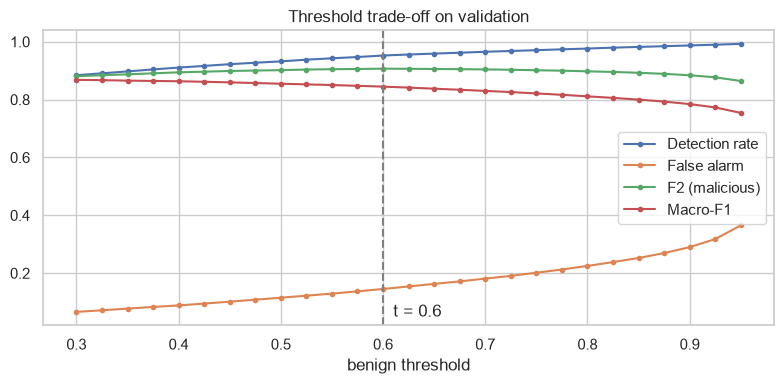

,threshold,detect_rate,false_alarm,f2_malicious,macro_f1
0,0.30,0.8842,0.0662,0.8806,0.8681
2,0.35,0.8972,0.0775,0.8872,0.8655
4,0.40,0.9106,0.0885,0.8941,0.8634
6,0.45,0.9224,0.1015,0.8989,0.8595
8,0.50,0.9321,0.1152,0.9017,0.8547
10,0.55,0.9427,0.1293,0.9050,0.8503
12,0.60,0.9523,0.1453,0.9068,0.8448
14,0.65,0.9589,0.1629,0.9057,0.8376
16,0.70,0.9652,0.1812,0.9042,0.8300
18,0.75,0.9707,0.2015,0.9014,0.8212


In [20]:
def predict_with_threshold(P, t):
    return np.where(P[:, 0] >= t, 0, 1 + P[:, 1:].argmax(1))

P_va = best_meta.predict_proba(Z_va)
curve = pd.DataFrame([dict(threshold=t, **metrics(y[va], predict_with_threshold(P_va, t)))
                      for t in np.round(np.arange(0.30, 0.96, 0.025), 3)])
THRESHOLD = float(curve.loc[curve["f2_malicious"].idxmax(), "threshold"])
print("chosen threshold (max F2 on validation):", THRESHOLD)

fig, ax = plt.subplots(figsize=(8, 4))
for col, label in [("detect_rate", "Detection rate"), ("false_alarm", "False alarm"), ("f2_malicious", "F2 (malicious)"), ("macro_f1", "Macro-F1")]:
    ax.plot(curve["threshold"], curve[col], marker=".", label=label)
ax.axvline(THRESHOLD, color="gray", ls="--"); ax.text(THRESHOLD + 0.01, 0.05, f"t = {THRESHOLD}")
ax.set_xlabel("benign threshold"); ax.set_title("Threshold trade-off on validation"); ax.legend(); plt.tight_layout(); plt.show()
curve[["threshold", "detect_rate", "false_alarm", "f2_malicious", "macro_f1"]].round(4).iloc[::2]

### ผลลัพธ์ที่ได้จากการรัน
- threshold ที่ F2 สูงสุดบน Validation = **0.6** (Detection 95.2%, False alarm 14.5%, F2 = 0.907)
  *(การรันครั้งก่อนบน scikit-learn เวอร์ชันอื่นได้ 0.625 ค่าต่างกันเล็กน้อยเพราะ HistGradientBoosting ได้ผลต่างกันเล็กน้อยระหว่างเวอร์ชัน)*
- กราฟแสดง trade-off: ยิ่ง threshold สูง ยิ่งจับได้มาก แต่เตือนผิดมากขึ้น
- ค่า 0.6 คือจุดที่ **ได้ Recall เพิ่มคุ้มกับ False alarm ที่ต้องแลก** ตามเกณฑ์ F2

## 5.6 สรุปการทดลองทั้งหมดบน Validation

,stage,model,params,features,macro_f1,detect_rate,false_alarm,rec_defacement,rec_malware,rec_phishing,fit_sec
0,5.1 lexical,LogisticRegression,,29 lexical,0.6046,0.8815,0.4205,0.7994,0.8092,0.7279,5.9
1,5.1 lexical,GaussianNB,,29 lexical,0.3023,0.9745,0.9374,0.9918,0.6455,0.0495,0.1
2,5.1 lexical,KNN,"k=15, 100k rows",29 lexical,0.7157,0.6220,0.0869,0.7982,0.6792,0.3315,0.0
3,5.1 lexical,DecisionTree,min_leaf=5,29 lexical,0.6560,0.8015,0.2856,0.7801,0.6788,0.6464,5.0
4,5.1 lexical,RandomForest,300 trees,29 lexical,0.7605,0.7325,0.1423,0.8051,0.6884,0.5876,49.1
5,5.1 lexical,HistGradientBoosting,"lr=0.1, leaves=31",29 lexical,0.6998,0.8554,0.3385,0.8469,0.6950,0.7745,43.0
6,5.1 lexical,HistGradientBoosting,"lr=0.1, leaves=127",29 lexical,0.7367,0.8362,0.2580,0.8181,0.6985,0.7646,34.3
7,5.1 lexical,HistGradientBoosting,"lr=0.05, leaves=255",29 lexical,0.7444,0.8351,0.2358,0.8216,0.7015,0.7592,56.7
8,5.2 representation,LinearSVC,C=0.3,char 3-5,0.8438,0.8289,0.0553,0.7821,0.7479,0.7752,33.0
9,5.2 representation,LinearSVC,C=0.3,char 2-6,0.8457,0.8246,0.0549,0.7805,0.7457,0.7830,43.1


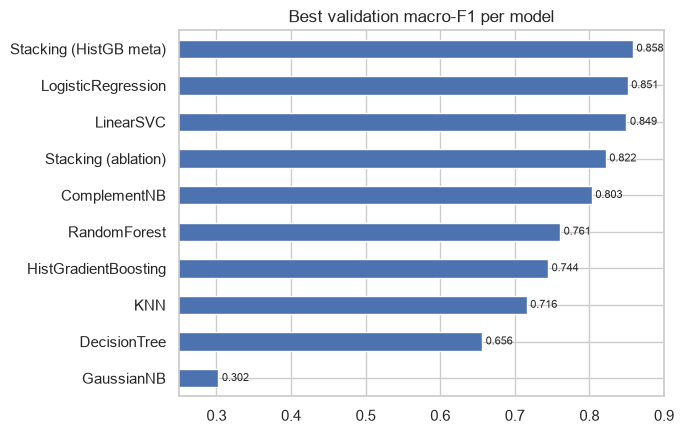

In [21]:
val_table = pd.DataFrame(experiments)
display(val_table[["stage"] + SHOW].round(4))

top = val_table.sort_values("macro_f1").drop_duplicates("model", keep="last")
ax = top.plot.barh(x="model", y="macro_f1", legend=False, figsize=(7, 4.5), color="#4C72B0")
ax.set_xlim(0.25, 0.9); ax.set_title("Best validation macro-F1 per model"); ax.set_ylabel("")
for p in ax.patches:
    ax.text(p.get_width() + 0.005, p.get_y() + p.get_height() / 2, f"{p.get_width():.3f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

# 6. Model Evaluation (Test set — เปิดครั้งเดียว)

ประเมินโมเดลที่ดีที่สุดของแต่ละกลุ่มบน **Test set (125,781 URL)** ซึ่งไม่เคยถูกใช้ในการตัดสินใจใดๆ มาก่อน

In [22]:
P_te = best_meta.predict_proba(Z_te)
finalists = {
    "RandomForest (lexical)": lex["RandomForest"].predict(L[te]),
    "HistGB (lexical)": best_hgb.predict(L[te]),
    f"ComplementNB (text, alpha={best_alpha})": best_nb.predict(XT[te]),
    f"LogisticRegression (text, C={best_lr_C})": best_lr.predict(XT[te]),
    f"LinearSVC (text, C={best_C})": best_svc.predict(XT[te]),
    "Stacking (argmax)": P_te.argmax(1),
    f"Stacking + threshold {THRESHOLD}  <- FINAL": predict_with_threshold(P_te, THRESHOLD),
}
test_table = pd.DataFrame([dict(model=k, **metrics(y[te], v)) for k, v in finalists.items()]).set_index("model")
test_table.round(4)

,acc,macro_f1,macro_precision,macro_recall,detect_rate,false_alarm,f2_malicious,rec_benign,rec_defacement,rec_malware,rec_phishing
model,,,,,,,,,,,
RandomForest (lexical),0.7915,0.7285,0.7899,0.6952,0.7020,0.1456,0.7020,0.8544,0.7623,0.5899,0.5742
HistGB (lexical),0.7546,0.7141,0.7535,0.7172,0.8003,0.2364,0.7573,0.7636,0.7694,0.5988,0.7370
"ComplementNB (text, alpha=0.2)",0.8631,0.8075,0.8577,0.7746,0.7097,0.0415,0.7401,0.9585,0.7915,0.8694,0.4789
"LogisticRegression (text, C=16)",0.8845,0.8552,0.8879,0.8339,0.8073,0.0569,0.8198,0.9431,0.7275,0.8955,0.7696
"LinearSVC (text, C=0.1)",0.8856,0.8542,0.8897,0.8282,0.7959,0.0494,0.8126,0.9506,0.7429,0.8942,0.7250
Stacking (argmax),0.8919,0.8764,0.8715,0.8912,0.9215,0.1039,0.8974,0.8961,0.9045,0.9118,0.8524
Stacking + threshold 0.6 <- FINAL,0.8725,0.8624,0.8518,0.8921,0.9429,0.1411,0.9012,0.8589,0.9141,0.9137,0.8815


### ผลลัพธ์ที่ได้จากการรัน (Test)

| โมเดล | Macro-F1 | Detection | False alarm | Recall deface | Recall malware | Recall phishing |
|---|---:|---:|---:|---:|---:|---:|
| RandomForest (lexical) | 0.729 | 70.2% | 14.6% | 76.2% | 59.0% | 57.4% |
| HistGB (lexical) | 0.714 | 80.0% | 23.6% | 76.9% | 59.9% | 73.7% |
| ComplementNB (text) | 0.808 | 71.0% | 4.2% | 79.2% | 86.9% | 47.9% |
| LogisticRegression (text) | 0.855 | 80.7% | 5.7% | 72.8% | 89.6% | 77.0% |
| LinearSVC (text) | 0.854 | 79.6% | 4.9% | 74.3% | 89.4% | 72.5% |
| Stacking (argmax) | **0.876** | 92.2% | 10.4% | 90.5% | 91.2% | 85.2% |
| **Stacking + threshold 0.6 (FINAL)** | 0.862 | **94.3%** | 14.1% | **91.4%** | **91.4%** | **88.2%** |

ผลบน Test สอดคล้องกับ Validation จึงไม่มีสัญญาณของ overfitting ต่อ Validation

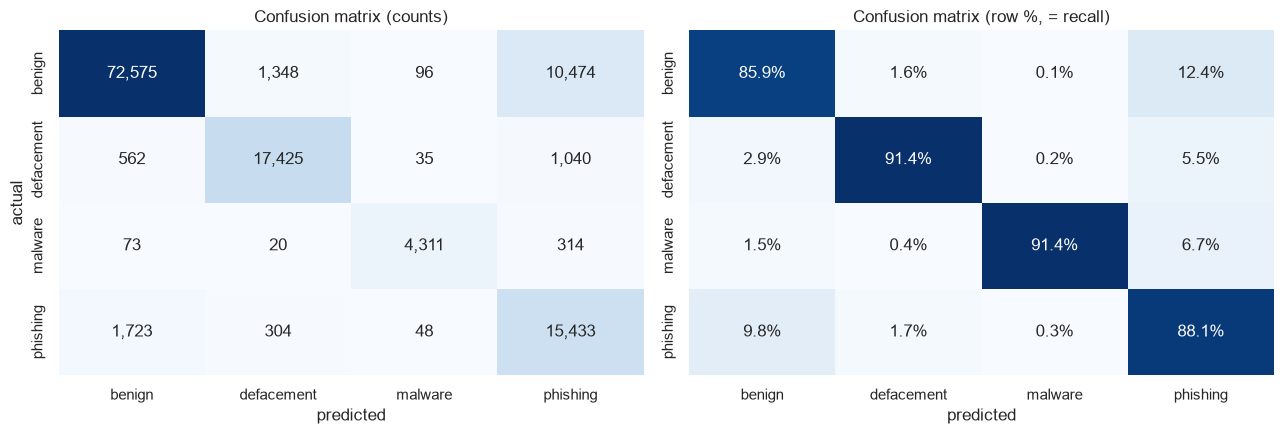

              precision    recall  f1-score   support

      benign     0.9685    0.8589    0.9105     84493
  defacement     0.9124    0.9141    0.9133     19062
     malware     0.9601    0.9137    0.9364      4718
    phishing     0.5661    0.8815    0.6895     17508

    accuracy                         0.8725    125781
   macro avg     0.8518    0.8921    0.8624    125781
weighted avg     0.9037    0.8725    0.8811    125781



In [23]:
final_pred = finalists[f"Stacking + threshold {THRESHOLD}  <- FINAL"]
cm = confusion_matrix(y[te], final_pred)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(pd.DataFrame(cm, LABELS, LABELS), annot=True, fmt=",d", cmap="Blues", ax=axes[0], cbar=False)
axes[0].set_title("Confusion matrix (counts)"); axes[0].set_xlabel("predicted"); axes[0].set_ylabel("actual")
sns.heatmap(pd.DataFrame(cm / cm.sum(1, keepdims=True), LABELS, LABELS), annot=True, fmt=".1%", cmap="Blues", ax=axes[1], cbar=False)
axes[1].set_title("Confusion matrix (row %, = recall)"); axes[1].set_xlabel("predicted"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()
print(classification_report(y[te], final_pred, target_names=LABELS, digits=4))

### ผลลัพธ์ที่ได้จากการรัน

| คลาส | Precision | Recall | F1 | จำนวน |
|---|---:|---:|---:|---:|
| benign | 0.969 | 0.859 | 0.911 | 84,493 |
| defacement | 0.912 | 0.914 | 0.913 | 19,062 |
| malware | 0.960 | 0.914 | 0.936 | 4,718 |
| phishing | **0.566** | 0.882 | 0.690 | 17,508 |

- URL อันตราย 41,288 รายการ หลุดเป็น benign **2,358 รายการ (5.7%)**
- ข้อผิดพลาดที่มากที่สุดคือ **benign ถูกเตือนว่าอันตราย 14.1%** (ส่วนใหญ่เป็น phishing) ทำให้ precision ของ phishing เหลือ 0.566 ซึ่งเป็นราคาที่ยอมจ่ายเพื่อให้ Recall สูง
- malware กับ defacement แทบไม่สับสนกันเอง ส่วนใหญ่ที่ผิดคือสับสนกับ phishing

## 6.1 เหตุผลในการเลือกโมเดลสุดท้าย

**โมเดลสุดท้าย: Stacking (LinearSVC + ComplementNB + Lexical → HistGradientBoosting) + threshold 0.6**

1. **Macro-F1 สูงที่สุด** ทั้งบน Validation (0.858) และ Test (0.876 แบบ argmax)
2. **ตรงเป้าหมายเรื่อง Recall:** จับ URL อันตรายได้ **94.3%** และ recall ของ defacement / malware เท่ากับ **0.914**
3. **Threshold เลือกจาก Validation** ด้วยเกณฑ์ F2 ไม่ได้ปรับจาก Test
4. **ทนต่อรูปแบบการพิมพ์:** เพราะ normalize ก่อนเสมอ ผู้ใช้จะพิมพ์ `https://www.x.com/` หรือ `x.com` ก็ได้ผลเดียวกัน
5. **ราคาที่ต้องจ่าย:** False alarm 14.1% ยอมรับได้สำหรับระบบเตือนภัย เพราะผู้ใช้ตรวจซ้ำได้ แต่ของอันตรายที่หลุดไปแก้ไขไม่ได้

> ข้อ 7–9 จะทดสอบโมเดลนี้กับข้อมูลภายนอก แล้วตรวจและแก้ label ก่อนเทรนใหม่

## 6.2 ตัวอย่าง URL อันตรายที่โมเดลพลาด (Error Analysis)

In [24]:
missed = te[(y[te] != 0) & (final_pred == 0)]
print("missed malicious:", len(missed), "by class:", pd.Series([LABELS[i] for i in y[missed]]).value_counts().to_dict())
pd.DataFrame({"url": defang(df["norm"].iloc[missed]).values, "true": df["type"].iloc[missed].values}).sample(12, random_state=1)

missed malicious: 2358 by class: {'phishing': 1723, 'defacement': 562, 'malware': 73}


,url,true
1204,server7online[.]com/www/fr[.]redirection[.]paypal[.]html,phishing
50,mnemonicmultimedia[.]com/billing/supporttickets[.]php,defacement
812,rid3481[.]org,phishing
1197,rediractionid547012016089540218057[.]blogspot[.]com,phishing
920,pleasedontlabelme[.]com,phishing
1606,en[.]wikipedia[.]org/wiki/Complex_programmable_logic_device,phishing
540,ebay[.]co[.]uk[.]natweng[.]com,phishing
397,barn[.]co[.]nz/www[.]luxuryvacationsnz[.]com,defacement
970,jtbgreece[.]com/en/japan/japan-highlights/osaka,defacement
936,aussiematesfeet[.]com,phishing


### ผลลัพธ์ที่ได้จากการรัน
- หลุดทั้งหมด **2,358 รายการ**: phishing 1,723, defacement 562, malware 73
- **พบ label noise ชัดเจน:** หลายรายการที่ "หลุด" เป็นหน้าเว็บจริงที่ถูกติด label ผิดว่า phishing
  เช่น `en.wikipedia.org/wiki/Complex_programmable_logic_device`, `sba.oakland.edu/faculty/mathieson/research`, `allexperts.com/browse.cgi?...`
  โมเดลทายว่า benign ซึ่งน่าจะ **ถูกต้องกว่า label** ดังนั้น recall จริงน่าจะสูงกว่าตัวเลขที่วัดได้
- ส่วนที่หลุดจริงคือ **phishing ที่ซ่อนชื่อแบรนด์ไว้ใน path หรือ subdomain บนโดเมนที่ดูธรรมดา**
  เช่น `server7online.com/www/fr.redirection.paypal.html`, `ebay.co.uk.natweng.com` ซึ่งต้องใช้ข้อมูลเพิ่ม เช่น อายุโดเมน (WHOIS) หรือเนื้อหาหน้าเว็บ
- *ข้อสังเกตเรื่อง label noise นี้ถูกตรวจอย่างเป็นระบบในข้อ 8*

# 7. ทดสอบกับข้อมูลภายนอก (รอบที่ 1: โมเดลที่เทรนจาก label เดิม)

Test set ในข้อ 6 มาจาก Kaggle ไฟล์เดียวกับ Train ถ้า label ใน Kaggle มีรูปแบบเฉพาะหรือมีข้อผิดพลาดซ้ำ ๆ Test ก็จะมีแบบเดียวกัน คะแนนจึงอาจดูดีเกินจริง
ข้อนี้จึงลองกับ **ข้อมูลจริงจากแหล่งอื่นที่ไม่เคยเห็น** เพื่อตรวจว่าใช้งานนอก Kaggle ได้จริงหรือไม่

| ชุด | ที่มา | คลาส | จำนวน |
|---|---|---|---|
| **PhishTank** | `online-valid.csv` ([phishtank.org](https://phishtank.org/developer_info.php)) ดึงข้อมูล 30 ก.ย. 2569: phishing ที่ยืนยันแล้วและยังออนไลน์ | phishing | 77,755 |
| **URLhaus** | abuse.ch `csv_recent` ([urlhaus.abuse.ch](https://urlhaus.abuse.ch/)): malware 30 วันล่าสุด | malware | 15,326 |
| **DeepURLBench** | Deep Instinct ([Hugging Face](https://huggingface.co/datasets/DeepInstinct/DeepURLBench)) สุ่มเท่ากันทุกคลาสจากทุกส่วนของไฟล์ (2010–2023) | benign / phishing / malware | 164,782 |

- ชุดภายนอก **ไม่มี defacement** จึงรายงาน recall รายคลาส ส่วน DeepURLBench รายงาน Macro-F1 แบบ 3 คลาสและ false alarm ด้วย
- รายงาน 2 มุม: **ทั้งหมด** และ **เฉพาะโดเมนที่ไม่มีใน Kaggle เลย** (registrable domain) เพราะ Kaggle มี URL บางส่วนจาก PhishTank รุ่นเก่า
- ทำนายด้วย `predict_urls` ตัวเดียวกับที่ Web App ใช้ และใช้ threshold ที่เลือกในข้อ 5.5 (0.6)

In [25]:
# ต้องติดตั้ง tldextract ก่อน (pip install tldextract)
import tldextract
_ext = tldextract.TLDExtract(suffix_list_urls=())          # bundled public-suffix list (offline)
_reg_cache = {}
def registrable(h):
    if h not in _reg_cache:
        _reg_cache[h] = (_ext(h).top_domain_under_public_suffix or h) if h else ""
    return _reg_cache[h]

reg_domain = host.map(registrable)                           # registrable domain of every Kaggle row (after cleaning)
kaggle_domains = set(reg_domain)
ext_sets = {
    "PhishTank": pd.read_csv("data/external/phishtank_online_valid.csv"),
    "URLhaus": pd.read_csv("data/external/urlhaus_recent.csv"),
    "DeepURLBench": pd.read_csv("data/external/deepurlbench_sample.csv"),
}
for d in ext_sets.values():
    h = split_parts(normalize(d["url"]))[0].str.replace(r":\d+$", "", regex=True)
    d["unseen_domain"] = ~h.map(registrable).isin(kaggle_domains).to_numpy()

def make_bundle(m):
    return dict(labels=LABELS, threshold=THRESHOLD, char_hash=char_hash(2, 6), word_hash=word_hash,
                tfidf_char=tfidf_char, tfidf_word=tfidf_word, **m)

ext_pred = {}
def eval_external(variant, bundle):
    rows = []
    for sname, d in ext_sets.items():
        pred = predict_urls(bundle, d["url"].tolist())["prediction"].to_numpy()
        ext_pred[(sname, variant)] = pred
        present = [c for c in LABELS if c in set(d["type"])]
        for scope, m_ in [("all", np.ones(len(d), bool)), ("unseen domain", d["unseen_domain"].to_numpy())]:
            yt, pp = d["type"].to_numpy()[m_], pred[m_]
            row = {"dataset": sname, "scope": scope, "model": variant, "rows": int(m_.sum())}
            row.update({f"recall_{c}": float((pp[yt == c] == c).mean()) for c in present})
            if "benign" in present:
                row["false_alarm"] = float((pp[yt == "benign"] != "benign").mean())
                row["macro_f1_3class"] = f1_score(yt, pp, labels=present, average="macro")
            row["detected_as_any_threat"] = float((pp[yt != "benign"] != "benign").mean())
            rows.append(row)
    return rows

bundle_original = make_bundle(dict(svc=best_svc, nb=best_nb, meta=best_meta))
start = time.time()
ext_round1 = pd.DataFrame(eval_external("Original", bundle_original)).set_index(["dataset", "scope"])
print(f"predicted {sum(len(d) for d in ext_sets.values()):,} external URLs in {time.time() - start:.0f}s")
ext_round1.drop(columns="model").round(4)

predicted 257,863 external URLs in 43s


rows  recall_phishing  detected_as_any_threat  recall_malware  recall_benign  false_alarm  macro_f1_3class
dataset      scope                                                                                                                      
PhishTank    all             77755           0.9359                  0.9481             NaN            NaN          NaN              NaN
             unseen domain   51525           0.9295                  0.9456             NaN            NaN          NaN              NaN
URLhaus      all             15326              NaN                  0.9962          0.9465            NaN          NaN              NaN
             unseen domain   15026              NaN                  0.9961          0.9472            NaN          NaN              NaN
DeepURLBench all            164782           0.7223                  0.9310          0.1221         0.2435       0.7565           0.3335
             unseen domain  141690           0.6926                  0.9550          0.1261         0.1952       0.8048           0.3083

### ผลลัพธ์ที่ได้จากการรัน
ทำนาย URL ภายนอก 257,863 รายการใน 43 วินาที

| ชุด | ขอบเขต | จำนวน | Recall phishing | Recall malware | Recall benign | False alarm | Macro-F1 (3 คลาส) | ทายว่าอันตราย (แบบใดก็ได้) |
|---|---|---:|---:|---:|---:|---:|---:|---:|
| PhishTank | ทั้งหมด | 77,755 | **93.6%** | – | – | – | – | 94.8% |
| PhishTank | โดเมนไม่เคยเห็น | 51,525 | 93.0% | – | – | – | – | 94.6% |
| URLhaus | ทั้งหมด | 15,326 | – | **94.7%** | – | – | – | 99.6% |
| URLhaus | โดเมนไม่เคยเห็น | 15,026 | – | 94.7% | – | – | – | 99.6% |
| DeepURLBench | ทั้งหมด | 164,782 | 72.2% | **12.2%** | **24.4%** | **75.7%** | **0.334** | 93.1% |
| DeepURLBench | โดเมนไม่เคยเห็น | 141,690 | 69.3% | 12.6% | 19.5% | 80.5% | 0.308 | 95.5% |

- **ข้อดี:** phishing จริงปัจจุบัน (PhishTank) จับได้ 93.6% และ malware (URLhaus) จับได้ 94.7% ตัวเลขแทบไม่ลดเมื่อดูเฉพาะโดเมนที่ไม่เคยเห็น แปลว่าไม่ได้แค่จำชื่อเว็บ
- **ข้อเสียร้ายแรง:** บน DeepURLBench **เว็บปกติถูกแจ้งเตือนผิด 75.7%** (Test ภายในแค่ 14.1%) และ malware ถูกทายถูกชนิดแค่ 12.2% Macro-F1 เหลือ 0.334

In [26]:
# ดูลึกว่าผิดแบบไหน: DeepURLBench (row % = recall), URLhaus แยก host แบบ IP, PhishTank แยกตามแบรนด์ที่ถูกปลอม
pt, uh, dub = ext_sets["PhishTank"], ext_sets["URLhaus"], ext_sets["DeepURLBench"]
dub_pred1 = ext_pred[("DeepURLBench", "Original")]
display((pd.crosstab(dub["type"], dub_pred1, normalize="index") * 100).reindex(columns=LABELS, fill_value=0).round(1))

uh_ip = lexical_features(normalize(uh["url"]).to_numpy(dtype=object))[:, LEXICAL_NAMES.index("is_ip")] > 0
uh_pred1 = ext_pred[("URLhaus", "Original")]
display(pd.DataFrame({"share of URLhaus": [uh_ip.mean(), (~uh_ip).mean()],
                      "recall_malware": [(uh_pred1[uh_ip] == "malware").mean(), (uh_pred1[~uh_ip] == "malware").mean()]},
                     index=["host = IP address", "host = domain name"]).round(3))

pt_pred1 = ext_pred[("PhishTank", "Original")]
top_targets = pt["target"].value_counts().head(8).index
display(pt.assign(hit=pt_pred1 == "phishing")[pt["target"].isin(top_targets)]
          .groupby("target").agg(rows=("hit", "size"), recall=("hit", "mean")).sort_values("rows", ascending=False).round(3))
missed_pt = pt[pt_pred1 == "benign"].sample(10, random_state=RANDOM_STATE)
print("PhishTank phishing ที่ถูกทายว่า benign (ตัวอย่าง):")
display(missed_pt.assign(url=defang(missed_pt["url"]))[["url", "target"]])

col_0,benign,defacement,malware,phishing
type,,,,
benign,24.4,13.5,4.2,57.9
malware,9.2,3.4,12.2,75.3
phishing,4.6,0.9,22.2,72.2


,share of URLhaus,recall_malware
host = IP address,0.896,0.985
host = domain name,0.104,0.617


,rows,recall
target,,
Other,67822,0.939
Allegro,4590,0.933
Internal Revenue Service,933,0.854
Amazon.com,893,0.822
Facebook,469,0.951
Microsoft,437,0.952
Bradesco,263,0.981
Netflix,254,0.945


PhishTank phishing ที่ถูกทายว่า benign (ตัวอย่าง):


,url,target
50889,hxxps://docs[.]google[.]com/presentation/d/e/2PACX-1vSZO3FNsqFxUlauG-2GHJxjJy22L9NDx44vZTakZefw_...,Other
2494,hxxps://dostawa2x[.]cam/o/ix118/7316975282811136#selectedbank9,Other
42442,hxxps://us12[.]campaign-archive[.]com/?u=938c4c575db6e3dfa324c1a47&id=3351235ef3,Other
44523,hxxps://us20[.]campaign-archive[.]com/?u=285c8bc038ed2212d4b526c88&id=7e54fd6db8,Other
52680,hxxps://autopassnor[.]wpenginepowered[.]com/autopass/pages/phone-number[.]php,Other
43682,hxxps://us3[.]campaign-archive[.]com/?e=5af4ee101f&i=*%7CITERATION_UNIQUE_ID%7C*&u=14bdf01a06fc6...,Other
44464,hxxps://us4[.]campaign-archive[.]com/?u=c5e9781123f6df45ee0ba33c4&id=19b3c3c212,Other
46916,hxxps://newo124[.]weebly[.]com/,Other
45170,hxxps://us11[.]campaign-archive[.]com/?u=c66fad67bdcd5bfe005ffc797&id=5820bd8ea7,Other
59705,hxxps://jhazmkkaan[.]blogspot[.]com/,Other


### ผลลัพธ์ที่ได้จากการรัน
**DeepURLBench (% ของแต่ละแถว)**

| จริง \ ทาย | benign | defacement | malware | phishing |
|---|---:|---:|---:|---:|
| benign | **24.4** | 13.5 | 4.2 | **57.9** |
| malware | 9.2 | 3.4 | **12.2** | **75.3** |
| phishing | 4.6 | 0.9 | 22.2 | **72.2** |

- เว็บปกติ **57.9% ถูกทายว่า phishing** และ 13.5% ถูกทายว่า defacement ทั้งที่ชุดนี้ไม่มี defacement เลย
- malware 75.3% ถูกทายว่า phishing (ยังนับว่า "อันตราย" แต่ผิดชนิด)

**URLhaus แยกตามชนิด host**

| host | สัดส่วน | Recall malware |
|---|---:|---:|
| IP address (เช่น `182.121.x.x:51965/i`) | 89.6% | **98.5%** |
| ชื่อโดเมน | 10.4% | **61.7%** |

ตัวเลข 94.7% ของ URLhaus จึงมาจาก URL แบบ IP เป็นหลัก ส่วน malware ที่ใช้ชื่อโดเมนจับได้แค่ 62%

**PhishTank แยกตามแบรนด์ที่ถูกปลอม:** Bradesco 98.1%, Microsoft 95.2%, Facebook 95.1%, Netflix 94.5%, Allegro 93.3%, IRS 85.4%, Amazon 82.2%
phishing ที่หลุดส่วนใหญ่ฝากบนบริการที่น่าเชื่อถือ เช่น `docs.google.com/presentation`, `*.campaign-archive.com` (Mailchimp), `weebly.com`, `blogspot.com`

### 7.1 สิ่งที่พบจากการทดสอบรอบที่ 1
1. โมเดล **จับของอันตรายได้ดี** (PhishTank 93.6%, URLhaus 94.7%) แต่ **แยกเว็บปกติจากแหล่งอื่นไม่ได้**: เว็บปกติใน DeepURLBench ถูกแจ้งเตือนผิด 75.7% ถ้าใช้งานจริงผู้ใช้จะเจอการแจ้งเตือนผิดเกือบทุกครั้ง
2. Test ภายใน (false alarm 14.1%) ไม่ได้เตือนเรื่องนี้ เพราะมาจาก Kaggle ไฟล์เดียวกับ Train ถ้า label ใน Kaggle ผิดแบบเป็นระบบ Test ก็ผิดแบบเดียวกัน
3. **สมมติฐาน:** Kaggle มี **เว็บปกติจำนวนมากที่ถูกติด label phishing** (ข้อ 3.4 และ 6.2) โมเดลจึงเรียนว่า "URL เว็บปกติที่มี path = phishing" แล้วนำไปใช้กับเว็บปกติจากแหล่งอื่น → ข้อ 8 ตรวจสมมติฐานนี้

# 8. หาสาเหตุ: ตรวจ Label Noise ใน Kaggle

หลักฐานจากข้อก่อนหน้าที่ชี้ว่า **label ใน Kaggle อาจผิด**
1. ข้อ 3.4: `github.com` ถูกติด phishing 30 จาก 33 แถว และ `microsoft.com` 366 แถว
2. ข้อ 6.2: URL ที่ "หลุด" หลายรายการเป็นหน้าเว็บจริง เช่น `en.wikipedia.org/wiki/...`, `cbsnews.com/...` แต่ถูกติด label phishing
3. ข้อ 7: บนข้อมูลภายนอก ผลแย่ลงชัดเจน โดยเฉพาะ **benign ถูกแจ้งเตือนผิด** และ **phishing ถูกทายเป็น benign**

ถ้าโมเดลเรียนจาก label ที่ผิด ก็จะทำผิดแบบเดียวกันกับข้อมูลจริง ข้อนี้จึงตรวจ label 3 วิธี จากง่ายไปละเอียด

## 8.1 ใช้ความรู้โดเมน: เทียบกับโดเมนยอดนิยม Tranco Top 10,000

[Tranco](https://tranco-list.eu) (Le Pochat et al., 2019) คือรายชื่อเว็บยอดนิยมที่ออกแบบให้ทนต่อการปั่นอันดับ ใช้ list ID **V349N** ดาวน์โหลดเมื่อ 30 ก.ย. 2569
นับแถวที่ label เป็น phishing/malware แต่ **registrable domain** (เช่น `docs.google.com` → `google.com`) อยู่ใน Top 10,000

> **ใช้ประกอบการอภิปรายเท่านั้น ห้ามเปลี่ยน label อัตโนมัติจากรายชื่อนี้** เพราะ phishing ที่ฝากบนบริการใหญ่มีอยู่จริง เช่น `sites.google.com`, `github.io`, `docs.google.com/forms`

In [27]:
tranco = pd.read_csv("data/external/tranco_top10k_V349N.csv")
on_top = reg_domain.isin(set(tranco["domain"])).to_numpy()
bad = df["type"].isin(["phishing", "malware"]).to_numpy()
print(f"rows on Tranco Top 10k: {on_top.sum():,} | labelled phishing/malware: {(on_top & bad).sum():,}")
display(pd.crosstab(df["type"], np.where(on_top, "Top 10k", "not in Top 10k"), margins=True))
rows_tb = np.flatnonzero(on_top & bad)
tranco_bad = pd.DataFrame({"domain": reg_domain.iloc[rows_tb].values, "type": df["type"].iloc[rows_tb].values, "row": rows_tb})
per_domain = (tranco_bad.groupby("domain").agg(rows=("row", "size"), phishing=("type", lambda s: (s == "phishing").sum()),
                                             malware=("type", lambda s: (s == "malware").sum()))
              .sort_values("rows", ascending=False))
per_domain.head(20)

rows on Tranco Top 10k: 167,211 | labelled phishing/malware: 22,705


col_0,Top 10k,not in Top 10k,All
type,,,
benign,144447,278021,422468
defacement,59,95249,95308
malware,1824,21767,23591
phishing,20881,66655,87536
All,167211,461692,628903


,rows,phishing,malware
domain,,,
ietf.org,3212,3212,0
angelfire.com,1306,1306,0
pastebin.com,987,0,987
tripod.com,871,871,0
google.com,821,616,205
sourceforge.net,713,713,0
yahoo.com,685,685,0
wikipedia.org,548,548,0
sharepoint.com,376,376,0


### ผลลัพธ์ที่ได้จากการรัน
- แถวบนโดเมน Top 10k มี **167,211 แถว** และในนั้น **22,705 แถว** ติด label phishing/malware (phishing 20,881, malware 1,824)

| โดเมน | แถว | phishing | malware | อ่านผล |
|---|---:|---:|---:|---|
| ietf.org | 3,212 | 3,212 | 0 | เอกสาร RFC แทบไม่มีทางเป็น phishing → **น่าจะ label ผิด** |
| angelfire.com | 1,306 | 1,306 | 0 | บริการฝากเว็บฟรี → phishing จริงเป็นไปได้ |
| pastebin.com | 987 | 0 | 987 | ใช้ฝาก payload จริงบ่อย → malware จริงเป็นไปได้ |
| tripod.com | 871 | 871 | 0 | บริการฝากเว็บฟรี |
| google.com | 821 | 616 | 205 | มีทั้ง Docs/Sites ที่ถูกใช้จริง และหน้าปกติ |
| sourceforge.net, yahoo.com, wikipedia.org | 713 / 685 / 548 | ทั้งหมด phishing | 0 | ส่วนใหญ่น่าจะเป็นหน้าปกติ |
| ibm.com, cnet.com, wired.com, w3.org, cmu.edu | 337 / 333 / 200 / 193 / 161 | ทั้งหมด phishing | 0 | เว็บองค์กร/สื่อ/มหาวิทยาลัย → **น่าจะ label ผิด** |

- **ข้อสังเกต:** แยกได้ 2 กลุ่มชัด คือ (1) บริการฝากเว็บ/ไฟล์ที่ถูกใช้ทำภัยจริง (angelfire, tripod, pastebin, blogspot, sharepoint) และ (2) เว็บองค์กรที่ไม่น่าเป็นภัย (ietf, ibm, cnet, w3, cmu) กลุ่มที่ 2 ตรงกับลักษณะของ **ชุด legitimate ของ PhishStorm** ที่ข้อ 8.2 จะแสดง
- ตามที่กำหนด **ไม่ได้เปลี่ยน label จากรายชื่อนี้** ใช้เป็นหลักฐานประกอบเท่านั้น

## 8.2 หลักฐานเฉพาะ: ข้อมูล PhishStorm ถูกสลับ label

ใน [Kaggle discussion ของ dataset นี้](https://www.kaggle.com/datasets/sid321axn/malicious-urls-dataset/discussion/431505) ผู้ใช้หลายคนพบว่าเว็บอย่าง `python.org`, `apache.org` ถูกติด phishing
และชี้ว่าผู้สร้างนำ **PhishStorm** (Marchal et al., 2014) มาต่อท้ายไฟล์โดย **สลับ label** เว็บปกติ ↔ phishing
ตรวจได้จากไฟล์เอง: หา "ก้อน" ของ label เดียวกันที่เรียงต่อกันยาว แล้วดู URL ตรงรอยต่อ

In [28]:
run_id = (raw["type"] != raw["type"].shift()).cumsum()
runs = raw.groupby(run_id).agg(start=("type", lambda s: s.index[0]), end=("type", lambda s: s.index[-1]),
                               label=("type", "first"), rows=("type", "size"))
display(runs[runs.rows >= 5000].tail(5))
PS_START, PS_END = 555_186, 651_190
print("ต้นช่วงที่ติด 'benign' (แถว 555,186):")
display(raw.iloc[PS_START:PS_START + 4].assign(url=lambda d: defang(d["url"])))
print("รอยต่อที่เริ่มติด 'phishing' (แถว 603,182):")
display(raw.iloc[603_180:603_186].assign(url=lambda d: defang(d["url"])))

ps = raw.iloc[PS_START:PS_END + 1]
ps = ps[ps["type"].isin(["benign", "phishing"])]
ps_true = dict(zip(normalize(ps["url"]), ps["type"].map({"benign": "phishing", "phishing": "benign"})))   # label that PhishStorm really has
in_block = df["norm"].isin(set(ps_true)).to_numpy()
split_name = np.empty(len(df), dtype=object); split_name[tr], split_name[va], split_name[te] = "train", "validation", "test"
print(f"rows of the cleaned dataset that come from the swapped block: {in_block.sum():,} ({in_block.mean():.1%})")
pd.crosstab(df["type"][in_block].rename("label ใน Kaggle"), split_name[in_block])

,start,end,label,rows
type,,,,
222201,520330,535218,phishing,14889
222202,535219,555185,malware,19967
222203,555186,573416,benign,18231
222209,573511,603181,benign,29671
222210,603182,651190,phishing,48009


ต้นช่วงที่ติด 'benign' (แถว 555,186):


,url,type
555186,nobell[.]it/70ffb52d079109dca5664cce6f317373782/login[.]SkyPe[.]com/en/cgi-bin/verification/logi...,benign
555187,www[.]dghjdgf[.]com/paypal[.]co[.]uk/cycgi-bin/webscrcmd=_home-customer&nav=1/loading[.]php,benign
555188,serviciosbys[.]com/paypal[.]cgi[.]bin[.]get-into[.]herf[.]secure[.]dispatch35463256rzr321654641d...,benign
555189,mail[.]printakid[.]com/www[.]online[.]americanexpress[.]com/index[.]html,benign


รอยต่อที่เริ่มติด 'phishing' (แถว 603,182):


,url,type
603180,conseguircreditos[.]webs[.]tl/,benign
603181,www[.]vbacreation[.]fr/includes/Archive/Connect/SignOn[.]php,benign
603182,www[.]sec[.]gov/edgar[.]shtml,phishing
603183,www[.]taxsites[.]com/associations2[.]html,phishing
603184,www[.]crescan[.]com/pakistanicma/,phishing
603185,www[.]ficpa[.]org/content/home[.]aspx,phishing


rows of the cleaned dataset that come from the swapped block: 90,667 (14.4%)


col_0,test,train,validation
label ใน Kaggle,,,
benign,8268,29522,4896
phishing,9265,33798,4918


### ผลลัพธ์ที่ได้จากการรัน
- พบก้อนต่อกัน 2 ก้อนท้ายไฟล์:
  - แถว **555,186–603,181** ติด label `benign` แต่ URL เป็น phishing ชัดเจน เช่น `login.SkyPe.com/.../verification`, `paypal.co.uk/cycgi-bin/webscr...`, `www.online.americanexpress.com/index.html` บน host แปลก
  - แถว **603,182–651,190** ติด label `phishing` แต่เป็นเว็บปกติ เช่น `sec.gov/edgar.shtml`, `ficpa.org` ก้อนนี้มี **48,009 แถวพอดี** เท่ากับจำนวน URL ปกติใน PhishStorm ต้นฉบับ
- หลังทำความสะอาด มีแถวจากช่วงนี้ **90,667 แถว (14.4% ของข้อมูล)** กระจายอยู่ทุกชุด:

| label ใน Kaggle | Train | Validation | Test |
|---|---:|---:|---:|
| benign (จริงคือ phishing) | 29,522 | 4,896 | 8,268 |
| phishing (จริงคือเว็บปกติ) | 33,798 | 4,918 | 9,265 |

- **ผลกระทบ:** phishing ใน Train มี 61,274 แถว แต่ **33,798 แถว (55%) เป็นเว็บปกติ** นี่อธิบายข้อ 7 ได้ตรง ๆ: โมเดลเรียนว่าเว็บปกติแบบ `องค์กร.com/path/page.html` = phishing
- **Validation และ Test ก็มี label ผิดชุดเดียวกัน** (9,814 และ 17,533 แถว) จึงต้องระวังเวลาใช้สองชุดนี้วัดผลในข้อ 9

## 8.3 ตรวจทั้ง dataset อย่างเป็นระบบ: Confident Learning

ข้อ 8.2 เจอเพราะมีคนชี้ให้ ส่วน label ผิดแบบอื่นที่ยังไม่มีใครเห็น ต้องใช้วิธีที่ตรวจได้ทุกแถว จึงใช้ **Confident Learning** (Northcutt et al., 2021) **เขียนเองด้วย scikit-learn** โดยไม่ใช้ `cleanlab`

**หลักการ:** ถ้าโมเดลที่ไม่เคยเห็นแถวนั้น (out-of-fold) มั่นใจมากว่าเป็นคลาสอื่น และมั่นใจน้อยว่าเป็น label เดิม แถวนั้นน่าจะติด label ผิด

| ขั้น | รายละเอียด |
|---|---|
| 1. Out-of-fold probability | `StratifiedGroupKFold(5)` แบ่งตาม hostname **บน TRAIN เท่านั้น** แต่ละ fold เทรน `LogisticRegression` บน char 2–6 + word TF-IDF แล้วทำนายแถวที่ไม่ได้ใช้เทรน |
| 2. Threshold รายคลาส | $t_j$ = ค่าเฉลี่ยของ $P(j)$ ในแถวที่ label เป็น $j$ ("ปกติแล้วโมเดลมั่นใจในคลาสนี้แค่ไหน") |
| 3. แถวต้องสงสัย | $P(\text{label เดิม}) < t_{\text{label}}$ **และ** มีคลาส $k$ อื่นที่ $P(k) \ge t_k$ |
| 4. Confident joint | ตาราง 4×4: label เดิม × label ที่น่าจะถูก (คลาสที่ผ่าน threshold และมีความน่าจะเป็นสูงสุด) |

- **ใช้ out-of-fold:** ถ้าให้โมเดลทำนายแถวที่ตัวเองเคยเห็น มันจะจำ label เดิมได้และมองไม่เห็นข้อผิดพลาด
- **แบ่ง fold ตาม hostname:** กันไม่ให้โมเดลใช้ URL อื่นของเว็บเดียวกันมายืนยัน label ที่ผิด
- **ตรวจเฉพาะ TRAIN:** Validation และ Test ต้องเป็นข้อมูลเดิมทุกแถว ถ้าแก้ label ของ Test ด้วย คะแนนจะสูงขึ้นเพราะเราไปแก้ข้อสอบเอง

In [29]:
from joblib import Parallel, delayed

# 8.3.1 feature: same char 2-6 + word representation as section 4, TRAIN rows only, IDF fitted on TRAIN
X_cl = sp.hstack([TfidfTransformer(sublinear_tf=True).fit_transform(char_hash(2, 6).transform(norm[tr])),
                  TfidfTransformer(sublinear_tf=True).fit_transform(word_hash.transform(norm[tr]))]).tocsr().astype(np.float32)
y_cl, g_cl = y[tr], groups[tr]

def _oof_fold(fit_idx, pred_idx):
    m = LogisticRegression(C=4, max_iter=200)        # no class_weight: per-class thresholds already handle imbalance
    m.fit(X_cl[fit_idx], y_cl[fit_idx])
    return pred_idx, m.predict_proba(X_cl[pred_idx])

cl_folds = list(StratifiedGroupKFold(5, shuffle=True, random_state=RANDOM_STATE).split(X_cl, y_cl, g_cl))
assert all(not set(g_cl[i]) & set(g_cl[j]) for i, j in cl_folds)            # no host shared between fit and predict
start = time.time()
P_oof = np.zeros((len(tr), 4))
for pred_idx, proba in Parallel(n_jobs=5)(delayed(_oof_fold)(i, j) for i, j in cl_folds):
    P_oof[pred_idx] = proba
print(f"TRAIN matrix {X_cl.shape}, out-of-fold probabilities in {time.time() - start:.0f}s")
print("out-of-fold accuracy vs given labels:", round(float((P_oof.argmax(1) == y_cl).mean()), 4))

TRAIN matrix (440305, 1572864), out-of-fold probabilities in 977s
out-of-fold accuracy vs given labels: 0.882


### ผลลัพธ์ที่ได้จากการรัน
- เมทริกซ์ Train: 440,305 แถว × 1,572,864 ฟีเจอร์ (char 2–6 + word)
- out-of-fold 5 fold (รันขนานกัน 5 งาน) ใช้เวลา **977 วินาที**
- ความแม่นของ out-of-fold เทียบกับ label เดิม = **0.882** ส่วนที่ไม่ตรงกัน 11.8% คือผู้สมัครเบื้องต้นที่อาจเป็น label ผิด

In [30]:
# 8.3.2 per-class threshold, suspicious rows, confident joint
idx = np.arange(len(tr))
t_class = np.array([P_oof[y_cl == j, j].mean() for j in range(4)])
above = P_oof >= t_class
p_given = P_oof[idx, y_cl]
other_above = above.copy(); other_above[idx, y_cl] = False
suspicious = (p_given < t_class[y_cl]) & other_above.any(1)
suggested = np.where(other_above, P_oof, -1).argmax(1)       # most probable OTHER class that passes its threshold
best_confident = np.where(above, P_oof, -1).argmax(1)        # for the confident joint (diagonal = label looks right)

display(pd.DataFrame({"threshold t_j": t_class.round(4)}, index=LABELS).T)
has_conf = above.any(1)
cj = pd.crosstab(pd.Series([LABELS[i] for i in y_cl[has_conf]], name="label เดิม"),
                 pd.Series([LABELS[i] for i in best_confident[has_conf]], name="label ที่น่าจะถูก")).reindex(index=LABELS, columns=LABELS, fill_value=0)
print("Confident joint (TRAIN rows that pass at least one class threshold):")
display(cj)
print(f"suspicious rows: {suspicious.sum():,} of {len(tr):,} TRAIN rows ({suspicious.mean():.2%})")
pd.crosstab(pd.Series([LABELS[i] for i in y_cl[suspicious]], name="label เดิม"),
            pd.Series([LABELS[i] for i in suggested[suspicious]], name="label ที่เสนอ"), margins=True)

,benign,defacement,malware,phishing
threshold t_j,0.9225,0.716,0.7604,0.6074


Confident joint (TRAIN rows that pass at least one class threshold):


label ที่น่าจะถูก,benign,defacement,malware,phishing
label เดิม,,,,
benign,223679,331,10,4771
defacement,3319,43967,6,1163
malware,687,168,12485,312
phishing,3181,41,26,33822


suspicious rows: 14,015 of 440,305 TRAIN rows (3.18%)


label ที่เสนอ,benign,defacement,malware,phishing,All
label เดิม,,,,,
benign,0,331,10,4771,5112
defacement,3319,0,6,1163,4488
malware,687,168,0,312,1167
phishing,3181,41,26,0,3248
All,7187,540,42,6246,14015


### ผลลัพธ์ที่ได้จากการรัน
**Threshold รายคลาส:** benign 0.923, defacement 0.716, malware 0.760, phishing 0.607
(benign สูงเพราะเป็นคลาสใหญ่ โมเดลจึงมั่นใจมาก ส่วน phishing ต่ำเพราะ label ปนกันมาก)

**Confident joint** (แถวที่ผ่าน threshold อย่างน้อย 1 คลาส)

| label เดิม \ น่าจะถูก | benign | defacement | malware | phishing |
|---|---:|---:|---:|---:|
| benign | **223,679** | 331 | 10 | 4,771 |
| defacement | 3,319 | **43,967** | 6 | 1,163 |
| malware | 687 | 168 | **12,485** | 312 |
| phishing | 3,181 | 41 | 26 | **33,822** |

- **แถวต้องสงสัย 14,015 แถว (3.18% ของ Train)** กลุ่มใหญ่ที่สุด: benign → phishing 4,771, defacement → benign 3,319, phishing → benign 3,181
- defacement → benign 3,319 แถวสอดคล้องกับที่ label defacement ของ dataset นี้ติดทั้งเว็บที่เคยถูกเจาะ ไม่ใช่เฉพาะหน้าที่ถูกเจาะ หน้าธรรมดาของเว็บเหล่านั้นจึงดูเหมือน benign

### 8.3.3 Confident Learning จับ label ผิดที่รู้คำตอบได้แค่ไหน
ใช้ช่วง PhishStorm จากข้อ 8.2 (รู้ label ที่ถูกแน่นอน เคยตรวจกับ PhishStorm ต้นฉบับแล้วตรง 100%) เป็น **เฉลย** เพื่อวัดความแม่นของ Confident Learning

In [31]:
in_ps = in_block[tr]
true_ps = np.array([LABELS.index(ps_true[n]) if n in ps_true else -1 for n in df["norm"].iloc[tr]])
wrong_ps = in_ps & (true_ps != y_cl)
check = pd.Series({
    "known-wrong TRAIN rows (PhishStorm swap)": int(wrong_ps.sum()),
    "flagged by Confident Learning": int((wrong_ps & suspicious).sum()),
    "recall on known errors": (wrong_ps & suspicious).sum() / wrong_ps.sum(),
    "share of flagged rows that are known errors": (wrong_ps & suspicious).sum() / suspicious.sum(),
    "suggested label = verified label": (suggested[wrong_ps & suspicious] == true_ps[wrong_ps & suspicious]).mean(),
    "flagged rows outside the PhishStorm block": int((suspicious & ~in_ps).sum()),
}, name="value")
check.to_frame()

,value
known-wrong TRAIN rows (PhishStorm swap),63320.000000
flagged by Confident Learning,3284.000000
recall on known errors,0.051864
share of flagged rows that are known errors,0.234320
suggested label = verified label,0.982948
flagged rows outside the PhishStorm block,10731.000000


### ผลลัพธ์ที่ได้จากการรัน
| ตัวชี้วัด | ค่า |
|---|---:|
| แถว Train ที่รู้แน่ว่า label ผิด (PhishStorm) | 63,320 |
| Confident Learning จับได้ | 3,284 |
| **Recall ต่อ label ผิดที่รู้คำตอบ** | **5.2%** |
| สัดส่วนของแถวต้องสงสัยที่เป็น label ผิดที่รู้คำตอบ | 23.4% |
| เมื่อจับได้ label ที่เสนอตรงกับเฉลย | **98.3%** |
| แถวต้องสงสัยนอกช่วง PhishStorm | 10,731 |

**ข้อค้นพบสำคัญ:** Confident Learning **แม่นเมื่อจับได้ (98.3%) แต่พลาดความผิดชุดใหญ่เกือบทั้งหมด (จับได้แค่ 5.2%)**
เหตุผล: label ผิดของ PhishStorm เป็น **ก้อนใหญ่ที่ผิดสม่ำเสมอ** (เว็บปกติ 33,798 แถวถูกติด phishing แบบเดียวกันทั้งหมด) โมเดลที่เทรนบน fold อื่นก็เห็นรูปแบบผิดนี้ซ้ำหลายหมื่นแถวจนเรียนตาม
out-of-fold probability จึง "เห็นด้วย" กับ label ที่ผิด Confident Learning จับได้ดีเฉพาะ label ผิดที่ **ขัดกับรูปแบบส่วนใหญ่** ไม่ใช่ความผิดที่เป็นระบบจนกลายเป็นรูปแบบเสียเอง

### 8.3.4 สุ่มแถวต้องสงสัย 30 แถวให้ตรวจด้วยตา
เป็นหลักฐานว่าแถวที่ถูกตัดสินว่า label ผิดนั้นผิดจริง (URL ถูก defang เพื่อไม่ให้กดเปิดโดยไม่ตั้งใจ)
คอลัมน์ `PhishStorm (เฉลย)` แสดง label ที่ถูกต้องเฉพาะแถวในช่วง PhishStorm ส่วนแถวอื่นต้องตัดสินด้วยตา ตารางถูกบันทึกเป็น `results/cl_manual_review_30.csv` ด้วย

In [32]:
p_new = P_oof[idx, suggested]
relabel_mask = suspicious & (p_new >= 0.95) & (p_given <= 0.05)
rng_rows = np.random.default_rng(RANDOM_STATE).choice(np.flatnonzero(suspicious), 30, replace=False)
review = pd.DataFrame({
    "url": defang(df["norm"].iloc[tr[rng_rows]]).values,
    "label เดิม": [LABELS[i] for i in y_cl[rng_rows]],
    "label ที่เสนอ": [LABELS[i] for i in suggested[rng_rows]],
    "P(label เดิม)": p_given[rng_rows].round(3),
    "P(ที่เสนอ)": p_new[rng_rows].round(3),
    "Relabel จะทำ": np.where(relabel_mask[rng_rows], "relabel", "drop"),
    "PhishStorm (เฉลย)": [LABELS[true_ps[i]] if in_ps[i] else "-" for i in rng_rows],
})
review.to_csv("results/cl_manual_review_30.csv", index=False, encoding="utf-8-sig")
review

,url,label เดิม,label ที่เสนอ,P(label เดิม),P(ที่เสนอ),Relabel จะทำ,PhishStorm (เฉลย)
0,audible[.]co[.]uk,phishing,benign,0.063,0.933,drop,-
1,advinno[.]com/products/fpga/103,defacement,phishing,0.005,0.917,drop,-
2,cerc[.]co[.]uk/environmental-software/ADMS-Urban-model[.]html,benign,phishing,0.215,0.753,drop,-
3,affiliatealmanac[.]com/systembanking/bdc965e7960bd70348dc38a981e34d8a,benign,phishing,0.346,0.646,drop,phishing
4,9779[.]info/%E5%88%9B%E6%84%8F%E7%AB%8B%E4%BD%93%E6%89%8B%E5%B7%A5%E5%89%AA%E8%B4%B4%E7%94%BB,malware,benign,0.011,0.982,relabel,-
5,9779[.]info/%E5%85%B3%E4%BA%8E%E9%92%B1%E7%9A%84%E5%89%AA%E8%B4%B4%E7%94%BB,malware,benign,0.011,0.978,relabel,-
6,sfhhz[.]com/contents/295/1706[.]html,defacement,benign,0.011,0.936,drop,-
7,dp-111[.]com/www[.]login?rid=LIbd1BYV,benign,phishing,0.318,0.672,drop,phishing
8,us[.]battle[.]net[.]acc[.]yz-login[.]com/login/en/login[.]html?app=wam&ref=hxxps:/www[.]worldofw...,benign,phishing,0.384,0.615,drop,phishing
9,rickandbobo[.]com/quiz/actors3[.]htm,defacement,benign,0.000,0.983,relabel,-


### ผลลัพธ์ที่ได้จากการรัน
ตารางนี้ให้ผู้ทำตรวจยืนยันทีละแถว ข้อสังเกตเบื้องต้น:
- **8 จาก 30 แถวอยู่ในช่วง PhishStorm** (แถวที่ 3, 7, 8, 12, 14, 15, 24, 25) และ **label ที่เสนอตรงกับเฉลยทั้ง 8 แถว**
- **defacement → benign 10 แถว** เช่น `rickandbobo.com/quiz/actors3.htm`, `easyphonia.com/rates-by-country/j`, `muscle-xpo.co.nz/gallery/...` เป็นหน้าธรรมดาของเว็บที่เคยถูกเจาะ ตัว URL ไม่มีร่องรอยการเจาะ Confident Learning จึงมองว่าเป็น benign
- **แถวที่ Confident Learning น่าจะเสนอผิด** เช่น `millmarkgroup.com/wp-admin/.../update_account/.../payment.php` และ `superpromocao.net78.net/...` (ถูกเสนอให้เป็น benign แต่รูปแบบเป็น phishing ชัด) และ `cdn.discordapp.com/attachments/...` (malware → benign ทั้งที่ Discord CDN ถูกใช้ฝาก malware บ่อย และแถวนี้ **ผ่านเกณฑ์ relabel** ด้วย P = 0.974)
- สรุป: แถวต้องสงสัยมีทั้งที่ผิดจริงและที่ Confident Learning ตัดสินผิด จึงไม่ควรเชื่อผลแบบอัตโนมัติทั้งหมด เกณฑ์ Relabel ที่เข้มงวด (≥ 0.95 / ≤ 0.05) ช่วยได้บางส่วนแต่ยังไม่ครบ

## 8.4 สร้าง Train ที่แก้ label แล้ว (แก้เฉพาะ TRAIN)

| ชุด Train | ทำอะไร | เหตุผล |
|---|---|---|
| **Original** | label เดิม | ใช้เทียบ |
| **Prune** (Confident Learning) | ลบแถวต้องสงสัยทั้งหมด | ง่ายและปลอดภัย แลกกับข้อมูลที่หายไป |
| **Relabel** (Confident Learning) | เปลี่ยน label **เฉพาะ** แถวที่ $P(\text{คลาสใหม่}) \ge 0.95$ และ $P(\text{label เดิม}) \le 0.05$ ส่วนแถวต้องสงสัยที่เหลือให้ลบ | แก้เฉพาะตอนที่มั่นใจมาก เพื่อไม่ให้ความผิดพลาดของโมเดลเราเองกลายเป็น label ใหม่ |
| **PhishStorm-fix** | สลับ label กลับเฉพาะช่วง PhishStorm (ข้อ 8.2) | แก้จากหลักฐานที่ยืนยันกับต้นฉบับแล้ว ใช้เทียบว่า Confident Learning ทำได้ใกล้เคียงแค่ไหน |

Validation (62,817 แถว) และ Test (125,781 แถว) **ไม่ถูกแตะ** มี `assert` ตรวจด้วย

In [33]:
y_va_before, y_te_before = y[va].copy(), y[te].copy()
drop_mask = suspicious & ~relabel_mask
y_relabel = np.where(relabel_mask, suggested, y_cl)
y_psfix = np.where(in_ps, np.where(true_ps >= 0, true_ps, y_cl), y_cl)

keep_all = np.ones(len(tr), bool)
VARIANT_DEF = {                      # name -> (TRAIN positions kept, labels for all TRAIN positions)
    "Original": (keep_all, y_cl),
    "Prune": (~suspicious, y_cl),
    "Relabel": (~drop_mask, y_relabel),
    "PhishStorm-fix": (keep_all, y_psfix),
}
VARIANTS = {name: (tr[keep], lab[keep]) for name, (keep, lab) in VARIANT_DEF.items()}
summary = pd.DataFrame({
    name: {"train rows": int(keep.sum()), "removed": int((~keep).sum()), "label changed": int((lab[keep] != y_cl[keep]).sum()),
           **{l: int((lab[keep] == c).sum()) for c, l in enumerate(LABELS)}}
    for name, (keep, lab) in VARIANT_DEF.items()}).T
display(summary)
print("Relabel: label เดิม -> label ใหม่")
display(pd.crosstab(pd.Series([LABELS[i] for i in y_cl[relabel_mask]], name="label เดิม"),
                    pd.Series([LABELS[i] for i in suggested[relabel_mask]], name="label ใหม่"), margins=True))
print(f"relabelled rows that are known PhishStorm errors: {(relabel_mask & wrong_ps).sum():,} of {relabel_mask.sum():,}")
assert np.array_equal(y[va], y_va_before) and np.array_equal(y[te], y_te_before)
print("Validation / Test labels unchanged ✓")

,train rows,removed,label changed,benign,defacement,malware,phishing
Original,440305,0,0,295728,66715,16588,61274
Prune,426290,14015,0,290616,62227,15421,58026
Relabel,431244,9061,4954,295135,62385,15430,58294
PhishStorm-fix,440305,0,63320,300004,66715,16588,56998


Relabel: label เดิม -> label ใหม่


label ใหม่,benign,defacement,malware,phishing,All
label เดิม,,,,,
benign,0,52,1,200,253
defacement,2192,0,0,43,2235
malware,525,103,0,25,653
phishing,1802,3,8,0,1813
All,4519,158,9,268,4954


relabelled rows that are known PhishStorm errors: 1,034 of 4,954
Validation / Test labels unchanged ✓


### ผลลัพธ์ที่ได้จากการรัน
| Train | แถว | ลบ | เปลี่ยน label | benign | defacement | malware | phishing |
|---|---:|---:|---:|---:|---:|---:|---:|
| Original | 440,305 | 0 | 0 | 295,728 | 66,715 | 16,588 | 61,274 |
| Prune | 426,290 | 14,015 | 0 | 290,616 | 62,227 | 15,421 | 58,026 |
| Relabel | 431,244 | 9,061 | 4,954 | 295,135 | 62,385 | 15,430 | 58,294 |
| PhishStorm-fix | 440,305 | 0 | 63,320 | 300,004 | 66,715 | 16,588 | 56,998 |

- Relabel เปลี่ยน label 4,954 แถว ส่วนใหญ่เป็น defacement → benign (2,192), phishing → benign (1,802), malware → benign (525) และมีแค่ **1,034 แถว** ที่เป็นความผิดของ PhishStorm
- PhishStorm-fix เปลี่ยน label 63,320 แถว มากกว่า Relabel 13 เท่า
- `assert` ยืนยันว่า label ของ Validation และ Test ไม่เปลี่ยน

# 9. เทรนใหม่และเปรียบเทียบ

เทรน **Stacking เดิมทุกประการ** ใหม่บน Train ทั้ง 4 แบบ:
- base: LinearSVC (C = `best_C`) + ComplementNB (α = `best_alpha`) บน char 2–6 + word TF-IDF พร้อม out-of-fold 3 fold ตาม hostname
- meta: HistGradientBoosting (hyperparameter เดียวกับ `best_meta`) + lexical 29 ตัว
- threshold เดียวกับข้อ 5.5 (0.6) ทุกแบบ

Original ก็เทรนใหม่ด้วยฟังก์ชันเดียวกัน ทั้ง 4 แบบจึงต่างกันแค่ **label ของ Train**
**เลือกวิธีด้วย Macro-F1 บน Validation เท่านั้น** แล้วเปิด Test ครั้งเดียว

In [34]:
META_PARAMS = best_meta.get_params()

def train_stack(rows, labels):
    oof_ = np.zeros((len(rows), 8), np.float32)
    for i, j in StratifiedGroupKFold(3, shuffle=True, random_state=1).split(rows, labels, groups[rows]):
        s_ = LinearSVC(class_weight="balanced", C=best_C).fit(XT[rows[i]], labels[i])
        n_ = ComplementNB(alpha=best_alpha).fit(XT[rows[i]], labels[i])
        oof_[j] = base_scores(s_, n_, rows[j])
    svc_ = LinearSVC(class_weight="balanced", C=best_C).fit(XT[rows], labels)
    nb_ = ComplementNB(alpha=best_alpha).fit(XT[rows], labels)
    meta_ = HistGradientBoostingClassifier(**META_PARAMS).fit(np.hstack([oof_, L[rows]]), labels)
    return dict(svc=svc_, nb=nb_, meta=meta_)

def stack_proba(m, rows):
    return m["meta"].predict_proba(np.hstack([base_scores(m["svc"], m["nb"], rows), L[rows]]))

def full_metrics(y_true, pred):
    p = precision_score(y_true, pred, average=None, labels=range(4), zero_division=0)
    return {**metrics(y_true, pred), **{f"prec_{l}": p[i] for i, l in enumerate(LABELS)}}

cl_models = {}
for name, (rows, labels) in VARIANTS.items():
    start = time.time(); cl_models[name] = train_stack(rows, labels)
    print(f"{name:15s} trained on {len(rows):,} rows in {time.time() - start:.0f}s")

COLS = ["macro_f1", "acc", "detect_rate", "false_alarm", "f2_malicious"] + [f"rec_{l}" for l in LABELS] + [f"prec_{l}" for l in LABELS]
val_cmp = pd.DataFrame({n: full_metrics(y[va], predict_with_threshold(stack_proba(m, va), THRESHOLD)) for n, m in cl_models.items()}).T[COLS]
BEST_VARIANT = val_cmp["macro_f1"].idxmax()
print("chosen on VALIDATION:", BEST_VARIANT)
val_cmp.round(4)

Original        trained on 440,305 rows in 207s


Prune           trained on 426,290 rows in 191s


Relabel         trained on 431,244 rows in 186s


PhishStorm-fix  trained on 440,305 rows in 198s


chosen on VALIDATION: Relabel


,macro_f1,acc,detect_rate,false_alarm,f2_malicious,rec_benign,rec_defacement,rec_malware,rec_phishing,prec_benign,prec_defacement,prec_malware,prec_phishing
Original,0.8398,0.8656,0.9532,0.1529,0.9048,0.8471,0.9242,0.7812,0.9132,0.9738,0.9111,0.9249,0.5525
Prune,0.8507,0.8784,0.9324,0.1265,0.8979,0.8735,0.9052,0.7943,0.8949,0.9637,0.9357,0.9322,0.5866
Relabel,0.8534,0.8765,0.9338,0.1306,0.8976,0.8694,0.9019,0.8232,0.8970,0.9643,0.9351,0.9363,0.5806
PhishStorm-fix,0.7710,0.7920,0.7517,0.1742,0.7356,0.8258,0.9429,0.8888,0.4391,0.8723,0.9069,0.9473,0.3570


### ผลลัพธ์ที่ได้จากการรัน (Validation)
แต่ละแบบเทรนใช้เวลาประมาณ 190–210 วินาที (threshold 0.6 ทุกแบบ)

| Train | Macro-F1 | Accuracy | Detection | False alarm | F2 | Recall phishing | Precision phishing |
|---|---:|---:|---:|---:|---:|---:|---:|
| Original | 0.840 | 0.866 | 95.3% | 15.3% | 0.905 | 91.3% | 55.3% |
| Prune | 0.851 | 0.878 | 93.2% | 12.7% | 0.898 | 89.5% | 58.7% |
| **Relabel** | **0.853** | 0.877 | 93.4% | 13.1% | 0.898 | 89.7% | 58.1% |
| PhishStorm-fix | 0.771 | 0.792 | 75.2% | 17.4% | 0.736 | 43.9% | 35.7% |

- **ตามกติกา (เลือกด้วย Macro-F1 บน Validation) ได้ Relabel** (+0.014 จาก Original) Prune ตามมาใกล้ ๆ
- PhishStorm-fix ได้ต่ำสุดอย่างชัดเจน ถ้ามองแค่ตารางนี้จะสรุปว่าการแก้ label ของ PhishStorm "ทำให้แย่ลง"
- **แต่** Validation มี label ผิดจาก PhishStorm ปนอยู่ 9,814 แถว (ข้อ 8.2) โมเดลที่แก้ label แล้วจะทายแถวเหล่านี้ "ถูกตามจริง" แต่ถูกนับว่าผิด ดูข้อ 9.1

In [35]:
test_cmp = pd.DataFrame({n: full_metrics(y[te], predict_with_threshold(stack_proba(m, te), THRESHOLD)) for n, m in cl_models.items()}).T[COLS]
test_cmp.round(4)

,macro_f1,acc,detect_rate,false_alarm,f2_malicious,rec_benign,rec_defacement,rec_malware,rec_phishing,prec_benign,prec_defacement,prec_malware,prec_phishing
Original,0.8580,0.8666,0.9461,0.1514,0.9000,0.8486,0.9190,0.9175,0.8829,0.9699,0.9022,0.9546,0.5540
Prune,0.8651,0.8772,0.9231,0.1252,0.8911,0.8748,0.8974,0.9082,0.8582,0.9588,0.9317,0.9730,0.5796
Relabel,0.8594,0.8722,0.9241,0.1328,0.8893,0.8672,0.8892,0.9106,0.8673,0.9590,0.9271,0.9509,0.5715
PhishStorm-fix,0.7783,0.7963,0.7637,0.1725,0.7463,0.8275,0.9252,0.9144,0.4732,0.8776,0.8940,0.9475,0.3796


### ผลลัพธ์ที่ได้จากการรัน (Test)
| Train | Macro-F1 | Accuracy | Detection | False alarm | F2 | Recall malware | Recall phishing | Precision phishing |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Original | 0.858 | 0.867 | 94.6% | 15.1% | 0.900 | 91.8% | 88.3% | 55.4% |
| Prune | **0.865** | 0.877 | 92.3% | 12.5% | 0.891 | 90.8% | 85.8% | 58.0% |
| **Relabel (เลือกจาก Validation)** | 0.859 | 0.872 | 92.4% | 13.3% | 0.889 | 91.1% | 86.7% | 57.2% |
| PhishStorm-fix | 0.778 | 0.796 | 76.4% | 17.3% | 0.746 | 91.4% | 47.3% | 38.0% |

- บน Test (label เดิม) Relabel ดีกว่า Original เล็กน้อย (+0.001 Macro-F1) และแจ้งเตือนผิดลดลงจาก 15.1% เป็น 13.3% แต่ Detection ลดจาก 94.6% เป็น 92.4%
- Prune ได้ Test สูงสุด (0.865) แต่ไม่ได้ถูกเลือกเพราะกติกาให้เลือกจาก Validation

## 9.1 ข้อมูลประกอบ: Test ที่ label ของช่วง PhishStorm ถูกต้อง
Test ชุดหลักยังมี label ผิดจากช่วง PhishStorm ปนอยู่ (ข้อ 8.2) โมเดลที่เรียนจาก label ที่ถูกจึงถูกหักคะแนนเมื่อตอบถูกแต่ไม่ตรงกับ label ที่ผิด
ตารางนี้เปลี่ยน label เฉพาะแถวในช่วง PhishStorm ของ Test เป็นค่าที่ยืนยันแล้ว **ใช้ประกอบการอ่านผลเท่านั้น** ไม่ได้ใช้เลือกวิธี

In [36]:
te_ps = in_block[te]
y_te_verified = y[te].copy()
y_te_verified[te_ps] = [LABELS.index(ps_true[n]) for n in df["norm"].iloc[te][te_ps]]
print(f"TEST rows in the PhishStorm block: {te_ps.sum():,} | labels corrected: {(y_te_verified != y[te]).sum():,}")
pd.DataFrame({n: full_metrics(y_te_verified, predict_with_threshold(stack_proba(m, te), THRESHOLD)) for n, m in cl_models.items()}).T[COLS[:5] + ["rec_phishing", "prec_phishing"]].round(4)

TEST rows in the PhishStorm block: 17,533 | labels corrected: 17,533


,macro_f1,acc,detect_rate,false_alarm,f2_malicious,rec_phishing,prec_phishing
Original,0.7851,0.7876,0.8330,0.2140,0.7878,0.6066,0.3589
Prune,0.7877,0.7959,0.8062,0.1896,0.7740,0.5714,0.3639
Relabel,0.7828,0.7909,0.8074,0.1970,0.7726,0.5809,0.3609
PhishStorm-fix,0.9043,0.9217,0.9592,0.0872,0.9323,0.9660,0.7308


### ผลลัพธ์ที่ได้จากการรัน
Test มี 17,533 แถวในช่วง PhishStorm และทุกแถวมี label ผิด

| Train | Macro-F1 | Accuracy | Detection | False alarm | F2 | Recall phishing | Precision phishing |
|---|---:|---:|---:|---:|---:|---:|---:|
| Original | 0.785 | 0.788 | 83.3% | 21.4% | 0.788 | 60.7% | 35.9% |
| Prune | 0.788 | 0.796 | 80.6% | 19.0% | 0.774 | 57.1% | 36.4% |
| Relabel | 0.783 | 0.791 | 80.7% | 19.7% | 0.773 | 58.1% | 36.1% |
| **PhishStorm-fix** | **0.904** | **0.922** | **95.9%** | **8.7%** | **0.932** | **96.6%** | **73.1%** |

**ผลกลับด้านทั้งหมด:** เมื่อวัดกับ label ที่ถูกต้อง PhishStorm-fix ดีที่สุดชัดเจน (Macro-F1 0.904 เทียบกับ 0.785, false alarm 8.7% เทียบกับ 21.4%) ส่วน Prune และ Relabel แทบไม่ต่างจาก Original
**บทเรียน:** เมื่อ Validation/Test มี label ผิดแบบเดียวกับ Train การเลือกโมเดลจาก Validation จะให้รางวัลโมเดลที่ **ทำผิดตาม label** และลงโทษโมเดลที่แก้ความผิดแล้ว (Northcutt et al., 2021b)

## 9.2 ทดสอบกับข้อมูลภายนอก (รอบที่ 2: หลังแก้ label)
ใช้ข้อมูลภายนอกชุดเดิมจากข้อ 7 ทำนายด้วยโมเดลที่เทรนจาก Train แต่ละแบบ แล้วเทียบกับรอบที่ 1

In [37]:
start = time.time()
ext_all = [eval_external(n, make_bundle(m)) for n, m in cl_models.items() if n != "Original"]
ext_round2 = pd.concat([ext_round1.reset_index().assign(model="Original (round 1)")] + [pd.DataFrame(r) for r in ext_all])
print(f"round 2 predictions in {time.time() - start:.0f}s")
key_cols = ["recall_phishing", "recall_malware", "recall_benign", "false_alarm", "macro_f1_3class", "detected_as_any_threat"]
ext_round2.set_index(["dataset", "scope", "model"])[["rows"] + key_cols].round(4)

round 2 predictions in 147s


rows  recall_phishing  recall_malware  recall_benign  false_alarm  macro_f1_3class  detected_as_any_threat
dataset      scope         model                                                                                                                           
PhishTank    all           Original (round 1)   77755           0.9359             NaN            NaN          NaN              NaN                  0.9481
             unseen domain Original (round 1)   51525           0.9295             NaN            NaN          NaN              NaN                  0.9456
URLhaus      all           Original (round 1)   15326              NaN          0.9465            NaN          NaN              NaN                  0.9962
             unseen domain Original (round 1)   15026              NaN          0.9472            NaN          NaN              NaN                  0.9961
DeepURLBench all           Original (round 1)  164782           0.7223          0.1221         0.2435       0.7565           0.3335                  0.9310
             unseen domain Original (round 1)  141690           0.6926          0.1261         0.1952       0.8048           0.3083                  0.9550
PhishTank    all           Prune                77755           0.9287             NaN            NaN          NaN              NaN                  0.9380
             unseen domain Prune                51525           0.9274             NaN            NaN          NaN              NaN                  0.9400
URLhaus      all           Prune                15326              NaN          0.9428            NaN          NaN              NaN                  0.9960
             unseen domain Prune                15026              NaN          0.9448            NaN          NaN              NaN                  0.9961
DeepURLBench all           Prune               164782           0.7190          0.1048         0.2831       0.7169           0.3393                  0.9143
             unseen domain Prune               141690           0.6839          0.1102         0.2365       0.7635           0.3167                  0.9435
PhishTank    all           Relabel              77755           0.9273             NaN            NaN          NaN              NaN                  0.9382
             unseen domain Relabel              51525           0.9269             NaN            NaN          NaN              NaN                  0.9420
URLhaus      all           Relabel              15326              NaN          0.9437            NaN          NaN              NaN                  0.9952
             unseen domain Relabel              15026              NaN          0.9449            NaN          NaN              NaN                  0.9952
DeepURLBench all           Relabel             164782           0.7221          0.1079         0.2741       0.7259           0.3384                  0.9211
             unseen domain Relabel             141690           0.6867          0.1124         0.2277       0.7723           0.3148                  0.9495
PhishTank    all           PhishStorm-fix       77755           0.8943             NaN            NaN          NaN              NaN                  0.9291
             unseen domain PhishStorm-fix       51525           0.8731             NaN            NaN          NaN              NaN                  0.9238
URLhaus      all           PhishStorm-fix       15326              NaN          0.9534            NaN          NaN              NaN                  0.9926
             unseen domain PhishStorm-fix       15026              NaN          0.9541            NaN          NaN              NaN                  0.9929
DeepURLBench all           PhishStorm-fix      164782           0.7596          0.1141         0.3265       0.6735           0.3733                  0.9172
             unseen domain PhishStorm-fix      141690           0.7226          0.1193         0.2734       0.7266           0.3487                  

### ผลลัพธ์ที่ได้จากการรัน
| ชุด | ตัวชี้วัด | Original (รอบ 1) | Prune | **Relabel** (เลือก) | PhishStorm-fix |
|---|---|---:|---:|---:|---:|
| PhishTank | Recall phishing | **93.6%** | 92.9% | 92.7% | 89.4% |
| URLhaus | Recall malware | 94.7% | 94.3% | 94.4% | **95.3%** |
| DeepURLBench | Macro-F1 (3 คลาส) | 0.334 | 0.339 | 0.338 | **0.373** |
| DeepURLBench | False alarm (เว็บปกติ) | 75.7% | 71.7% | 72.6% | **67.4%** |
| DeepURLBench | Recall phishing | 72.2% | 71.9% | 72.2% | **76.0%** |
| DeepURLBench | Recall malware | **12.2%** | 10.5% | 10.8% | 11.4% |

(เฉพาะโดเมนที่ไม่เคยเห็นให้ผลทิศทางเดียวกัน เช่น false alarm ของ DeepURLBench: 80.5% → 77.2% ด้วย Relabel และ 72.7% ด้วย PhishStorm-fix)

- **Relabel (ตัวที่กติกาเลือก):** ดีขึ้นเล็กน้อย false alarm บน DeepURLBench ลดลง 3.1 จุด แต่ recall บน PhishTank ลด 0.9 จุด
- **PhishStorm-fix:** ดีที่สุดบน DeepURLBench (false alarm ลด 8.3 จุด, Macro-F1 +0.04) และ URLhaus แต่ recall บน PhishTank ลด 4.2 จุด
- ไม่มีวิธีไหนแก้ปัญหาหลักได้ เว็บปกติจาก DeepURLBench ยังถูกแจ้งเตือนผิดเกิน 2 ใน 3 แปลว่า label noise เป็นแค่ **ส่วนหนึ่ง** ของสาเหตุ อีกส่วนคือ **benign ใน Kaggle มีรูปแบบต่างจากเว็บปกติทั่วไป** (ข้อมูลต่างแหล่ง)

In [38]:
# ดูลึกเฉพาะวิธีที่เลือกเทียบกับรอบที่ 1
dub_pred2 = ext_pred[("DeepURLBench", BEST_VARIANT)] if BEST_VARIANT != "Original" else dub_pred1
print(f"DeepURLBench row %  (round 1 Original -> {BEST_VARIANT})")
display(pd.concat({"round 1": pd.crosstab(dub["type"], dub_pred1, normalize="index"),
                   BEST_VARIANT: pd.crosstab(dub["type"], dub_pred2, normalize="index")}, axis=1).fillna(0).mul(100).round(1))
pt_pred2 = ext_pred[("PhishTank", BEST_VARIANT)] if BEST_VARIANT != "Original" else pt_pred1
pd.DataFrame({"round 1": pt.assign(hit=pt_pred1 == "phishing").groupby("target").hit.mean(),
              BEST_VARIANT: pt.assign(hit=pt_pred2 == "phishing").groupby("target").hit.mean()}).loc[top_targets].round(3)

DeepURLBench row %  (round 1 Original -> Relabel)


round 1                             Relabel                            
col_0     benign defacement malware phishing  benign defacement malware phishing
type                                                                            
benign      24.4       13.5     4.2     57.9    27.4       12.3     3.6     56.7
malware      9.2        3.4    12.2     75.3    10.4        3.3    10.8     75.4
phishing     4.6        0.9    22.2     72.2     5.3        0.9    21.5     72.2

,round 1,Relabel
target,,
Other,0.939,0.932
Allegro,0.933,0.902
Internal Revenue Service,0.854,0.862
Amazon.com,0.822,0.768
Facebook,0.951,0.936
Microsoft,0.952,0.957
Bradesco,0.981,0.973
Netflix,0.945,0.925


### ผลลัพธ์ที่ได้จากการรัน
**DeepURLBench (% ของแต่ละแถว) รอบ 1 → Relabel:** เว็บปกติทายถูกเพิ่มจาก 24.4% เป็น 27.4% และถูกทายว่า phishing ลดจาก 57.9% เป็น 56.7% ส่วน malware และ phishing แทบไม่เปลี่ยน

**PhishTank แยกตามแบรนด์ รอบ 1 → Relabel:** ส่วนใหญ่ลดลงเล็กน้อย เช่น Allegro 93.3% → 90.2%, Amazon 82.2% → 76.8% ส่วน IRS 85.4% → 86.2% และ Microsoft 95.2% → 95.7% ดีขึ้นเล็กน้อย
เมื่อลบหรือเปลี่ยน label phishing บางส่วนเป็น benign โมเดลก็ระวังการตัดสินว่าเป็น phishing มากขึ้น จับ phishing จริงได้น้อยลงเล็กน้อย

# 10. บันทึกโมเดลและทดสอบแบบที่ Web App ใช้งานจริง

บันทึกทุกส่วนที่จำเป็นต่อการทำนายไว้ในไฟล์เดียว แล้ว **โหลดกลับมา** ทดสอบกับ URL ที่ผู้ใช้อาจพิมพ์
เพื่อยืนยันว่าไฟล์นี้ใช้กับ Web App ได้จริง

โมเดลที่บันทึกเป็น `url_model.joblib` คือ **Stacking ที่เทรนใหม่บน Train แบบที่ชนะในข้อ 9** และเก็บโมเดลเดิมไว้เป็น `url_model_original.joblib`

In [39]:
joblib.dump(bundle_original, "url_model_original.joblib", compress=3)
bundle = make_bundle(cl_models[BEST_VARIANT])      # improved model chosen on validation in section 9
print("web-app model trained on:", BEST_VARIANT)
joblib.dump(bundle, "url_model.joblib", compress=3)
print(f"saved url_model.joblib ({Path('url_model.joblib').stat().st_size / 1e6:.0f} MB)")

loaded = joblib.load("url_model.joblib")
demo = [
    "https://www.google.com", "google.com", "https://www.youtube.com/watch?v=dQw4w9WgXcQ",
    "https://th.wikipedia.org/wiki/Thailand", "https://github.com/",
    "http://paypal-account-verify.secure-login.xyz/update/index.php",
    "http://192.168.10.5/bank/login.php?user=1",
    "appleid-apple-com.signin-verify.top/account",
    "http://free-bonus-gift.tk/download/setup.exe",
    "http://www.example-school.ac.th/index.php?option=com_content&view=article&id=70",
]
result = predict_urls(loaded, demo)
result.assign(url=defang(result["url"])).round(3)

web-app model trained on: Relabel


saved url_model.joblib (116 MB)


,url,prediction,P(benign),P(defacement),P(malware),P(phishing)
0,hxxps://www[.]google[.]com,benign,0.949,0.000,0.000,0.051
1,google[.]com,benign,0.949,0.000,0.000,0.051
2,hxxps://www[.]youtube[.]com/watch?v=dQw4w9WgXcQ,benign,0.992,0.002,0.000,0.006
3,hxxps://th[.]wikipedia[.]org/wiki/Thailand,benign,1.000,0.000,0.000,0.000
4,hxxps://github[.]com/,phishing,0.000,0.000,0.000,1.000
5,hxxp://paypal-account-verify[.]secure-login[.]xyz/update/index[.]php,phishing,0.000,0.000,0.000,1.000
6,hxxp://192[.]168[.]10[.]5/bank/login[.]php?user=1,phishing,0.002,0.000,0.005,0.993
7,appleid-apple-com[.]signin-verify[.]top/account,phishing,0.000,0.000,0.000,1.000
8,hxxp://free-bonus-gift[.]tk/download/setup[.]exe,malware,0.000,0.000,1.000,0.000
9,hxxp://www[.]example-school[.]ac[.]th/index[.]php?option=com_content&view=article&id=70,defacement,0.000,1.000,0.000,0.000


### ผลลัพธ์ที่ได้จากการรัน
- บันทึก `url_model.joblib` (116 MB) จาก **Relabel** ตามกติกาเลือกด้วย Validation และเก็บโมเดลเดิมไว้เป็น `url_model_original.joblib`
- ทดสอบ 10 URL ด้วย `predict_urls` เดียวกับ Web App ทายถูก **9 จาก 10**:
  - `google.com` และ `https://www.google.com` ได้ P(benign) = 0.949 เท่ากันทุกตำแหน่ง ยืนยันว่า normalize ทำงาน
  - youtube, wikipedia = benign; paypal/apple ปลอม และ `192.168.10.5/bank/login.php` = phishing; `.exe` บน `.tk` = malware; Joomla `index.php?option=com_content` = defacement
  - **ผิด 1 รายการ:** `https://github.com/` ถูกทายว่า phishing (P = 1.00) เพราะใน dataset `github.com` ถูกติด phishing 30 จาก 33 แถว (ข้อ 3.4) ซึ่ง Confident Learning ไม่ได้แก้ให้

# 11. Discussion

## จุดเด่น
- **เชื่อถือได้ในเชิงวิธีการ:** ตรวจและแก้ bias ของรูปแบบ URL, ลบข้อมูลซ้ำ/ขัดแย้ง, แบ่งข้อมูลตาม host, เลือกทุกอย่างบน Validation และเปิด Test ครั้งเดียว
- **Recall สูง:** บน Test จับ URL อันตรายได้ 94.3% และบนข้อมูลจริงภายนอกจับ phishing ของ PhishTank ได้ 93.6% และ malware ของ URLhaus ได้ 94.7% ตัวเลขแทบไม่ลดกับโดเมนที่ไม่เคยเห็น
- **ทนต่อรูปแบบการพิมพ์ของผู้ใช้:** ผลไม่เปลี่ยนเมื่อเติมหรือตัด `https://www.`
- **อธิบายได้ทุกขั้น:** มี ablation ยืนยันว่า lexical, stacking และ threshold ช่วยจริง และตรวจสาเหตุของผลที่ไม่ดีจนเจอ

## จุดอ่อน
- **ใช้กับเว็บปกติจากแหล่งอื่นไม่ได้:** บน DeepURLBench เว็บปกติถูกแจ้งเตือนผิด 72–76% ขึ้นกับวิธี (Test ภายใน 14%)
- **malware ที่ใช้ชื่อโดเมน** จับได้แค่ 62% ส่วนที่ใช้ IP จับได้ 98.5% และ malware ของ DeepURLBench ถูกทายเป็น phishing เกือบทั้งหมด
- **phishing บนบริการที่น่าเชื่อถือ** (Google Docs, Mailchimp, Weebly, Blogspot) มักหลุด เพราะข้อความ URL ดูปกติ
- ไฟล์โมเดลใหญ่ (~116 MB) จาก hashing 1.5 ล้านมิติ

## ปัญหาที่พบ
1. **Bias ของ scheme / www / `/`** ทำให้โมเดลแบบทั่วไปได้คะแนนสูงหลอกตา แก้ด้วยการ normalize
2. **Label ขัดแย้งแฝง ~4,000 คู่** หลัง normalize (URL เดียวกันแต่ label ต่างกัน) จึงลบทั้งคู่
3. **Label ผิดจาก PhishStorm ถูกสลับ:** 90,667 แถว (14.4%) อยู่ทั้งใน Train, Validation และ Test ทำให้ phishing ใน Train ถึง 55% เป็นเว็บปกติ
4. **Confident Learning มีข้อจำกัด:** แม่นเมื่อจับได้ (98.3%) แต่จับ label ผิดชุดใหญ่ได้แค่ 5.2% เพราะความผิดสม่ำเสมอจนโมเดลเรียนตาม และตรวจด้วยตาพบว่ามันเสนอผิดบางแถว (เช่น phishing บน `wp-admin/.../payment.php`, malware บน Discord CDN)
5. **Validation ที่มี label ผิดทำให้เลือกโมเดลผิด:** กติกาเลือกจาก Validation เลือก Relabel แต่เมื่อวัดกับ label ที่ยืนยันแล้ว PhishStorm-fix ดีกว่ามาก (Macro-F1 0.904 เทียบกับ 0.783) และดีกว่าบน DeepURLBench/URLhaus ข้อแลกเปลี่ยนคือ recall บน PhishTank ลด 4.2 จุด

## แนวทางพัฒนาในอนาคต
- **แก้ label ของ PhishStorm ใน Validation ด้วย** (ยังคงไม่แตะ Test) เพื่อให้การเลือกโมเดลวัดกับ label ที่ถูก ถ้าทำแล้วผลตามข้อ 9.1 ชี้ว่า PhishStorm-fix จะถูกเลือก
- **เพิ่มเว็บปกติจากหลายแหล่ง** (เช่น URL จริงจากโดเมนใน Tranco) และ malware แบบโดเมน เพื่อลด false alarm กับข้อมูลภายนอก
- ใช้ Confident Learning ร่วมกับการตรวจด้วยคนสำหรับกลุ่มที่เป็นระบบ (ตรวจ "ก้อน" ของแหล่งข้อมูล แทนการดูทีละแถว)
- เพิ่ม feature ภายนอก URL: อายุโดเมน (WHOIS), DNS, SSL certificate, เนื้อหาหน้าเว็บ

# References
1. Siddhartha, M. *Malicious URLs Dataset*. Kaggle. https://www.kaggle.com/datasets/sid321axn/malicious-urls-dataset
2. Canadian Institute for Cybersecurity. *ISCX-URL2016*. https://www.unb.ca/cic/datasets/url-2016.html
3. Marchal, S. et al. *PhishStorm – Phishing/Legitimate URL Dataset*. Aalto University.
4. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR 12, 2825–2830.
5. Wolpert, D. H. (1992). *Stacked Generalization*. Neural Networks 5(2), 241–259.
6. Ma, J., Saul, L. K., Savage, S., & Voelker, G. M. (2009). *Beyond Blacklists: Learning to Detect Malicious Web Sites from Suspicious URLs*. KDD.
7. Berners-Lee, T., Fielding, R., & Masinter, L. *RFC 3986: URI Generic Syntax*. https://www.rfc-editor.org/rfc/rfc3986
8. Northcutt, C. G., Jiang, L., & Chuang, I. L. (2021). Confident Learning: Estimating Uncertainty in Dataset Labels. *Journal of Artificial Intelligence Research*, 70, 1373–1411. https://arxiv.org/abs/1911.00068
9. Brodley, C. E., & Friedl, M. A. (1999). Identifying Mislabeled Training Data. *Journal of Artificial Intelligence Research*, 11, 131–167. https://arxiv.org/abs/1106.0219
10. Northcutt, C. G., Athalye, A., & Mueller, J. (2021b). Pervasive Label Errors in Test Sets Destabilize Machine Learning Benchmarks. *NeurIPS Datasets and Benchmarks*. https://arxiv.org/abs/2103.14749
11. Frénay, B., & Verleysen, M. (2014). Classification in the Presence of Label Noise: A Survey. *IEEE Transactions on Neural Networks and Learning Systems*, 25(5), 845–869. doi:10.1109/TNNLS.2013.2292894
12. Le Pochat, V., Van Goethem, T., Tajalizadehkhoob, S., Korczyński, M., & Joosen, W. (2019). Tranco: A Research-Oriented Top Sites Ranking Hardened Against Manipulation. *NDSS*. https://arxiv.org/abs/1806.01156 (list ID V349N, https://tranco-list.eu)
13. cleanlab: https://github.com/cleanlab/cleanlab (ไลบรารีของผู้เขียน Confident Learning ใช้เป็นแหล่งอ้างอิงวิธี ไม่ได้ใช้ในโค้ด)
14. Kaggle discussion: *Why are websites like www.python.org/community/jobs/ ... marked as phishing?* https://www.kaggle.com/datasets/sid321axn/malicious-urls-dataset/discussion/431505
15. Marchal, S., François, J., State, R., & Engel, T. (2014). PhishStorm: Detecting Phishing With Streaming Analytics. *IEEE Transactions on Network and Service Management*, 11(4), 458–471.
16. PhishTank. *Developer information / online-valid data*. https://phishtank.org/developer_info.php (ดึงข้อมูล 30 ก.ย. 2569)
17. abuse.ch. *URLhaus*. https://urlhaus.abuse.ch/ (csv_recent, 30 ก.ย. 2569)
18. Deep Instinct. *DeepURLBench*. Hugging Face. https://huggingface.co/datasets/DeepInstinct/DeepURLBench